In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import mutual_info_classif
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DIAGNOSIS_MAP = {1.0: 'CN', 2.0: 'MCI', 3.0: 'Dementia'}
DIAG_COLORS = {'CN': '#2ecc71', 'MCI': '#f39c12', 'Dementia': '#e74c3c'}

GENOTYPE_COLS = [c for c in ['GENOTYPE_2/2', 'GENOTYPE_2/3', 'GENOTYPE_2/4',
                              'GENOTYPE_3/3', 'GENOTYPE_3/4', 'GENOTYPE_4/4']]

CDR_DOMAINS = {
    'CDMEMORY': ['CDMEMORY_0.0', 'CDMEMORY_0.5', 'CDMEMORY_1.0', 'CDMEMORY_2.0', 'CDMEMORY_3.0'],
    'CDORIENT': ['CDORIENT_0.0', 'CDORIENT_0.5', 'CDORIENT_1.0', 'CDORIENT_2.0', 'CDORIENT_3.0'],
    'CDJUDGE':  ['CDJUDGE_0.0',  'CDJUDGE_0.5',  'CDJUDGE_1.0',  'CDJUDGE_2.0',  'CDJUDGE_3.0'],
    'CDCOMMUN': ['CDCOMMUN_0.0', 'CDCOMMUN_0.5', 'CDCOMMUN_1.0', 'CDCOMMUN_2.0', 'CDCOMMUN_3.0'],
    'CDHOME':   ['CDHOME_0.0',   'CDHOME_0.5',   'CDHOME_1.0',   'CDHOME_2.0',   'CDHOME_3.0'],
    'CDCARE':   ['CDCARE_0.0',   'CDCARE_1.0',    'CDCARE_2.0',   'CDCARE_3.0'],
}

df = pd.read_csv('../data/balanced_diagnosis_3.csv')
df['DIAGNOSIS_LABEL'] = df['DIAGNOSIS'].map(DIAGNOSIS_MAP)
print(f"Shape: {df.shape}")
print("Libraries loaded and data ready.")

Shape: (13668, 37)
Libraries loaded and data ready.


## Section 1: Data Quality and Overview

In [4]:
print("=== Data Info ===")
df.info()
print("\n=== Missing Values ===")
print(df.isnull().sum().to_string())
print(f"\nTotal nulls: {df.isnull().sum().sum()}")

=== Data Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13668 entries, 0 to 13667
Data columns (total 37 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   GENOTYPE_2/2     13668 non-null  float64
 1   GENOTYPE_2/3     13668 non-null  float64
 2   GENOTYPE_2/4     13668 non-null  float64
 3   GENOTYPE_3/3     13668 non-null  float64
 4   GENOTYPE_3/4     13668 non-null  float64
 5   GENOTYPE_4/4     13668 non-null  float64
 6   CDMEMORY_0.0     13668 non-null  float64
 7   CDMEMORY_0.5     13668 non-null  float64
 8   CDMEMORY_1.0     13668 non-null  float64
 9   CDMEMORY_2.0     13668 non-null  float64
 10  CDMEMORY_3.0     13668 non-null  float64
 11  CDORIENT_0.0     13668 non-null  float64
 12  CDORIENT_0.5     13668 non-null  float64
 13  CDORIENT_1.0     13668 non-null  float64
 14  CDORIENT_2.0     13668 non-null  float64
 15  CDORIENT_3.0     13668 non-null  float64
 16  CDJUDGE_0.0      13668 non-null  float64

In [5]:
print("=== Value Validation ===")
feature_cols = [c for c in df.columns if c not in ['DIAGNOSIS', 'DIAGNOSIS_LABEL']]
unique_vals = df[feature_cols].stack().unique()
print(f"Unique values in feature columns: {sorted(unique_vals)}")

print("\n=== Mutual Exclusivity Check (one-hot groups sum to 1) ===")
groups = {'GENOTYPE': GENOTYPE_COLS, **CDR_DOMAINS}
for name, cols in groups.items():
    valid_cols = [c for c in cols if c in df.columns]
    row_sums = df[valid_cols].sum(axis=1)
    bad = (row_sums != 1.0).sum()
    print(f"  {name:10s}: {len(valid_cols)} cols | rows not summing to 1: {bad} / {len(df)}")

print("\n=== Descriptive Statistics ===")
df.describe().T

=== Value Validation ===
Unique values in feature columns: [np.float64(0.0), np.float64(1.0)]

=== Mutual Exclusivity Check (one-hot groups sum to 1) ===
  GENOTYPE  : 6 cols | rows not summing to 1: 1006 / 13668
  CDMEMORY  : 5 cols | rows not summing to 1: 984 / 13668
  CDORIENT  : 5 cols | rows not summing to 1: 1052 / 13668
  CDJUDGE   : 5 cols | rows not summing to 1: 1020 / 13668
  CDCOMMUN  : 5 cols | rows not summing to 1: 1156 / 13668
  CDHOME    : 5 cols | rows not summing to 1: 1210 / 13668
  CDCARE    : 4 cols | rows not summing to 1: 836 / 13668

=== Descriptive Statistics ===


,count,mean,std,min,25%,50%,75%,max
GENOTYPE_2/2,13668.0,0.002195,0.046800,0.0,0.0,0.0,0.0,1.0
GENOTYPE_2/3,13668.0,0.071481,0.257636,0.0,0.0,0.0,0.0,1.0
GENOTYPE_2/4,13668.0,0.023266,0.150753,0.0,0.0,0.0,0.0,1.0
GENOTYPE_3/3,13668.0,0.453029,0.497807,0.0,0.0,0.0,1.0,1.0
GENOTYPE_3/4,13668.0,0.329529,0.470059,0.0,0.0,0.0,1.0,1.0
GENOTYPE_4/4,13668.0,0.113916,0.317720,0.0,0.0,0.0,0.0,1.0
CDMEMORY_0.0,13668.0,0.330407,0.470377,0.0,0.0,0.0,1.0,1.0
CDMEMORY_0.5,13668.0,0.304653,0.460277,0.0,0.0,0.0,1.0,1.0
CDMEMORY_1.0,13668.0,0.236172,0.424745,0.0,0.0,0.0,0.0,1.0
CDMEMORY_2.0,13668.0,0.071481,0.257636,0.0,0.0,0.0,0.0,1.0


## Section 2: Target Variable (DIAGNOSIS) Analysis

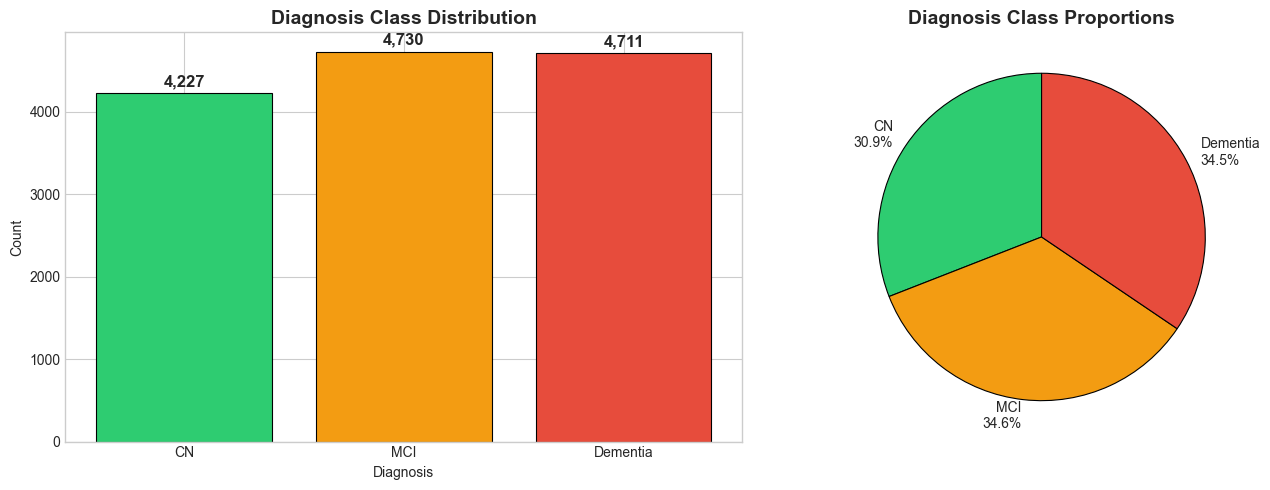

Class counts:
DIAGNOSIS_LABEL
CN          4227
MCI         4730
Dementia    4711

Balance ratio (min/max): 0.894


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

counts = df['DIAGNOSIS_LABEL'].value_counts().reindex(['CN', 'MCI', 'Dementia'])
bars = axes[0].bar(counts.index, counts.values,
                   color=[DIAG_COLORS[k] for k in counts.index], edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 f'{val:,}', ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[0].set_title('Diagnosis Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].set_xlabel('Diagnosis')

pcts = counts / counts.sum() * 100
axes[1].pie(pcts, labels=[f'{k}\n{v:.1f}%' for k, v in pcts.items()],
            colors=[DIAG_COLORS[k] for k in pcts.index],
            startangle=90, wedgeprops={'edgecolor': 'black', 'linewidth': 0.8})
axes[1].set_title('Diagnosis Class Proportions', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"Class counts:\n{counts.to_string()}")
print(f"\nBalance ratio (min/max): {counts.min()/counts.max():.3f}")

## Section 3: APOE Genotype Analysis

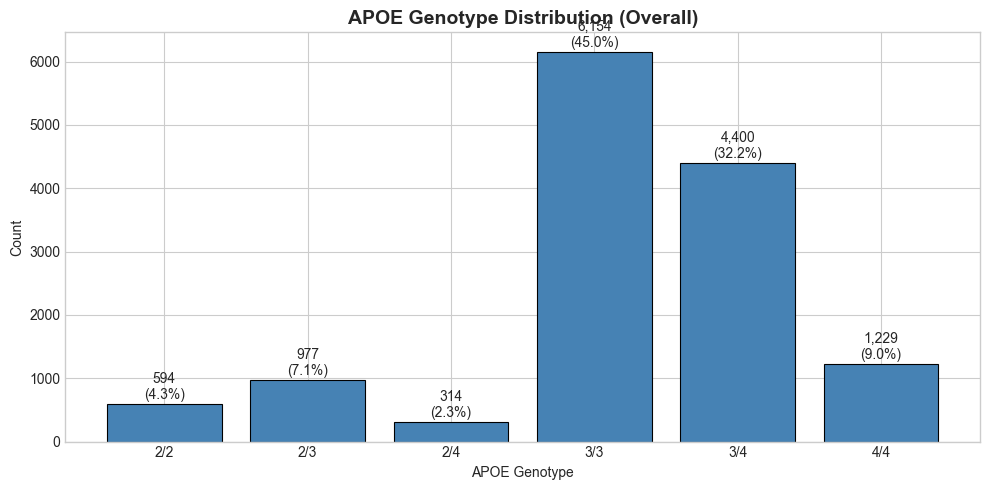

In [7]:
df['GENOTYPE'] = df[GENOTYPE_COLS].idxmax(axis=1).str.replace('GENOTYPE_', '')

fig, ax = plt.subplots(figsize=(10, 5))
geno_order = ['2/2', '2/3', '2/4', '3/3', '3/4', '4/4']
geno_counts = df['GENOTYPE'].value_counts().reindex(geno_order, fill_value=0)

bars = ax.bar(geno_counts.index, geno_counts.values, color='steelblue', edgecolor='black', linewidth=0.8)
for bar, val in zip(bars, geno_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', va='bottom', fontsize=10)
ax.set_title('APOE Genotype Distribution (Overall)', fontsize=14, fontweight='bold')
ax.set_xlabel('APOE Genotype')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()

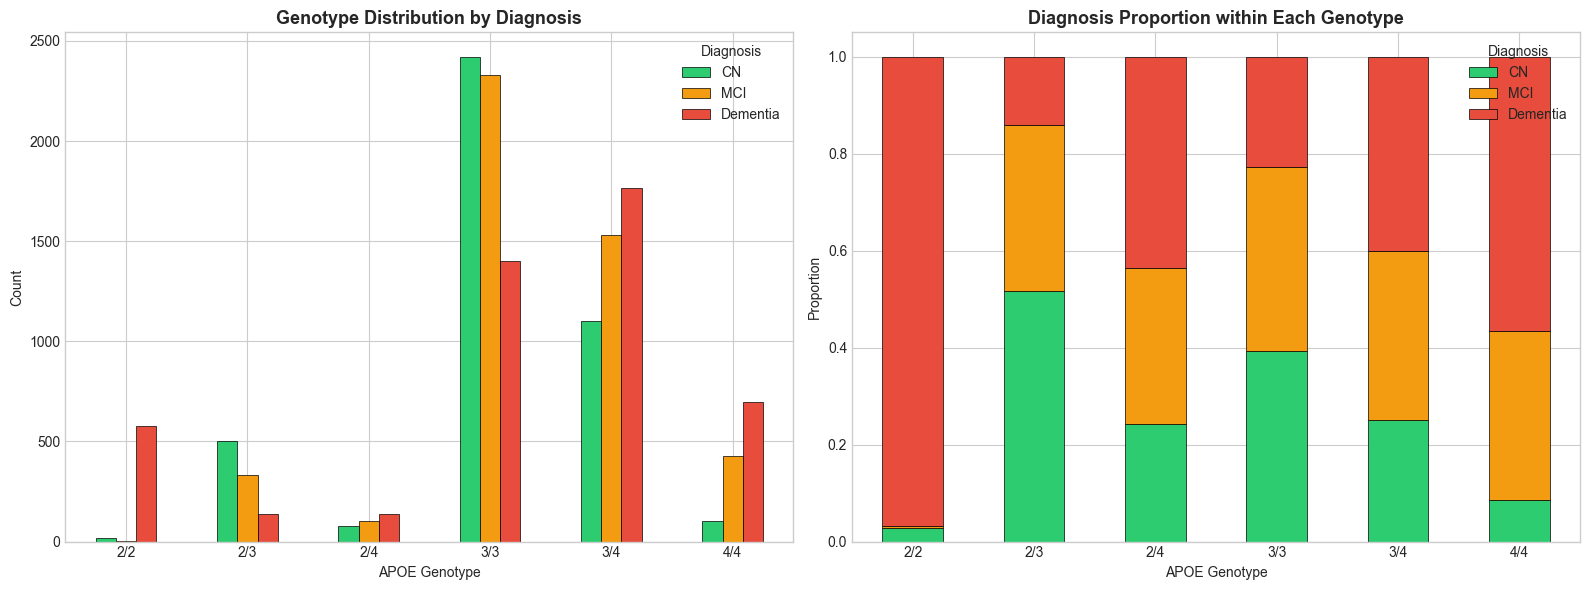

Chi-squared test of independence (Genotype vs Diagnosis):
  χ² = 2154.94, p = 0.00e+00, dof = 10
  Significant at α=0.05

Normalized proportions:
DIAGNOSIS_LABEL     CN    MCI  Dementia
GENOTYPE                               
2/2              0.029  0.003     0.968
2/3              0.516  0.343     0.141
2/4              0.242  0.322     0.436
3/3              0.394  0.379     0.228
3/4              0.251  0.348     0.401
4/4              0.085  0.349     0.566


In [8]:
geno_order = ['2/2', '2/3', '2/4', '3/3', '3/4', '4/4']
diag_order = ['CN', 'MCI', 'Dementia']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

ct = pd.crosstab(df['GENOTYPE'], df['DIAGNOSIS_LABEL'])
ct = ct.reindex(index=geno_order, columns=diag_order, fill_value=0)
ct.plot(kind='bar', ax=axes[0], color=[DIAG_COLORS[d] for d in diag_order], edgecolor='black', linewidth=0.5)
axes[0].set_title('Genotype Distribution by Diagnosis', fontsize=13, fontweight='bold')
axes[0].set_xlabel('APOE Genotype')
axes[0].set_ylabel('Count')
axes[0].legend(title='Diagnosis')
axes[0].tick_params(axis='x', rotation=0)

ct_norm = ct.div(ct.sum(axis=1), axis=0)
ct_norm.plot(kind='bar', stacked=True, ax=axes[1],
             color=[DIAG_COLORS[d] for d in diag_order], edgecolor='black', linewidth=0.5)
axes[1].set_title('Diagnosis Proportion within Each Genotype', fontsize=13, fontweight='bold')
axes[1].set_xlabel('APOE Genotype')
axes[1].set_ylabel('Proportion')
axes[1].legend(title='Diagnosis')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

chi2, p, dof, expected = stats.chi2_contingency(ct)
print(f"Chi-squared test of independence (Genotype vs Diagnosis):")
print(f"  χ² = {chi2:.2f}, p = {p:.2e}, dof = {dof}")
print(f"  {'Significant' if p < 0.05 else 'Not significant'} at α=0.05")

print(f"\nNormalized proportions:\n{ct_norm.round(3).to_string()}")

## Section 4: CDR Domain Analysis

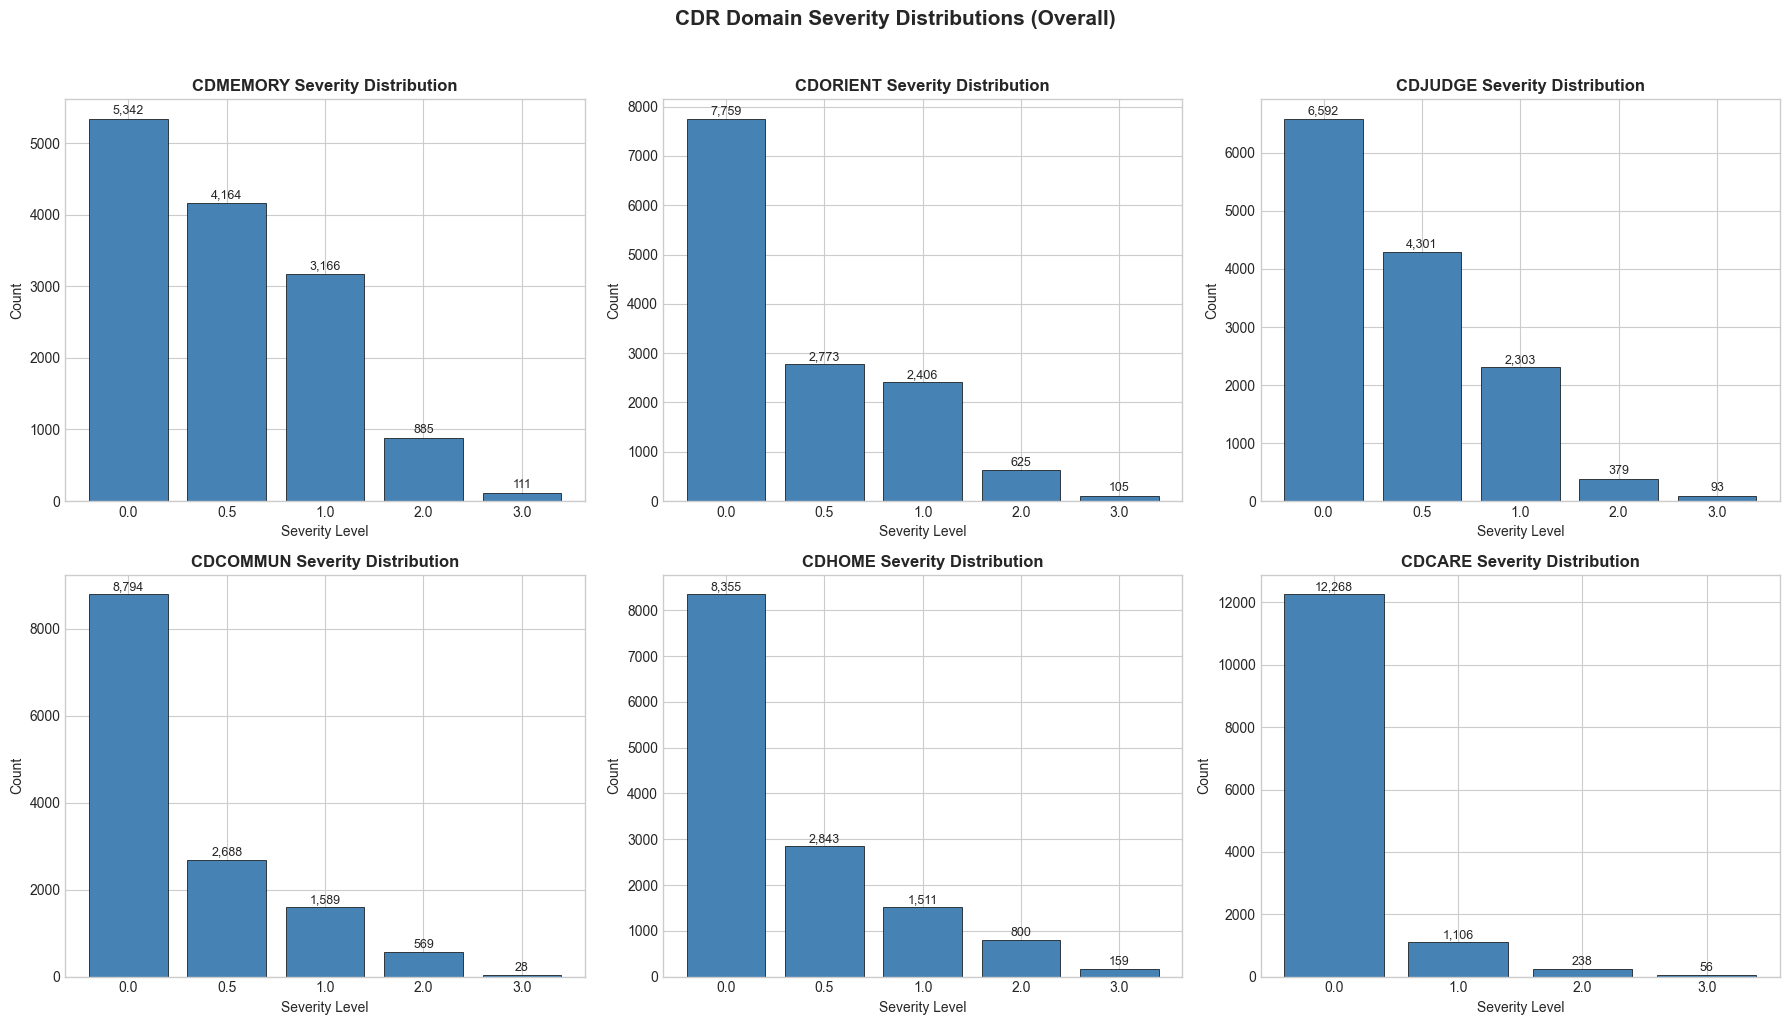

In [10]:
def reverse_onehot_domain(df, domain, cols):
    """Extract ordinal severity from one-hot columns."""
    levels = []
    for c in cols:
        level = float(c.split('_')[-1])
        levels.append(level)
    sub = df[cols].values
    return np.array(levels)[sub.argmax(axis=1)]

for domain, cols in CDR_DOMAINS.items():
    valid = [c for c in cols if c in df.columns]
    df[domain] = reverse_onehot_domain(df, domain, valid)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, (domain, cols) in enumerate(CDR_DOMAINS.items()):
    levels = sorted(df[domain].unique())
    vc = df[domain].value_counts().reindex(levels, fill_value=0)
    axes[i].bar([str(l) for l in vc.index], vc.values, color='steelblue', edgecolor='black', linewidth=0.5)
    for bar, val in zip(axes[i].patches, vc.values):
        if val > 0:
            axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                         f'{val:,}', ha='center', va='bottom', fontsize=9)
    axes[i].set_title(f'{domain} Severity Distribution', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Severity Level')
    axes[i].set_ylabel('Count')

plt.suptitle('CDR Domain Severity Distributions (Overall)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

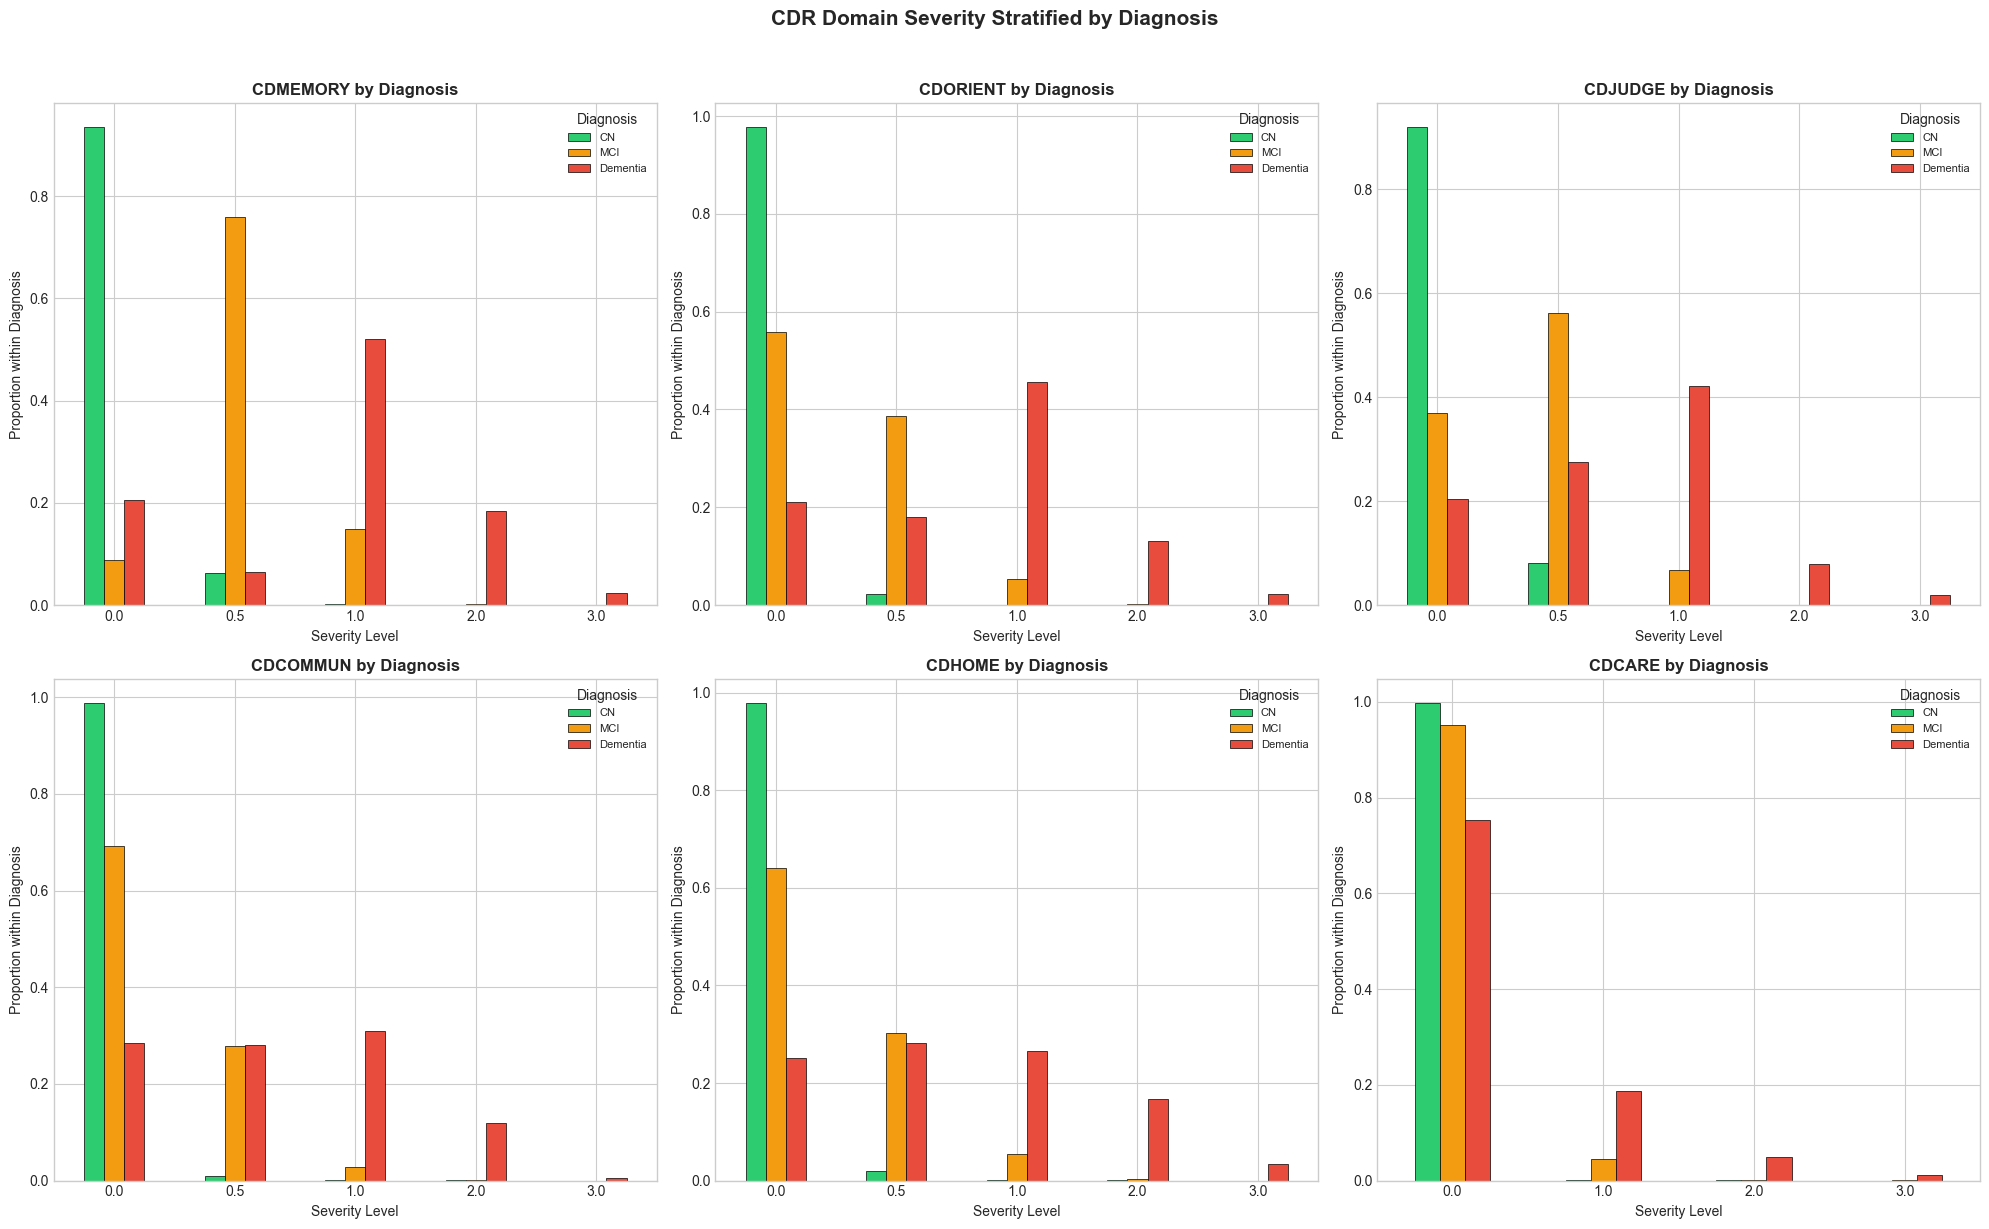

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()
diag_order = ['CN', 'MCI', 'Dementia']

for i, domain in enumerate(CDR_DOMAINS.keys()):
    ct = pd.crosstab(df[domain], df['DIAGNOSIS_LABEL'])
    ct = ct.reindex(columns=diag_order)
    ct_norm = ct.div(ct.sum(axis=0), axis=1)

    ct_norm.plot(kind='bar', ax=axes[i], color=[DIAG_COLORS[d] for d in diag_order],
                 edgecolor='black', linewidth=0.5)
    axes[i].set_title(f'{domain} by Diagnosis', fontsize=12, fontweight='bold')
    axes[i].set_xlabel('Severity Level')
    axes[i].set_ylabel('Proportion within Diagnosis')
    axes[i].legend(title='Diagnosis', fontsize=8)
    axes[i].tick_params(axis='x', rotation=0)

plt.suptitle('CDR Domain Severity Stratified by Diagnosis', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

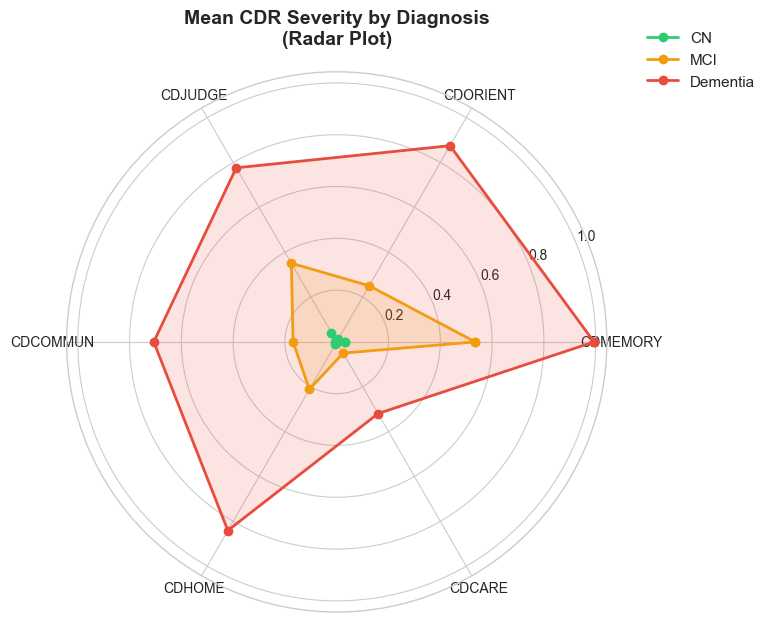

Mean severity per domain per diagnosis:
                 CDMEMORY  CDORIENT  CDJUDGE  CDCOMMUN  CDHOME  CDCARE
DIAGNOSIS_LABEL                                                       
CN                  0.033     0.012    0.041     0.007   0.011   0.002
MCI                 0.535     0.250    0.351     0.168   0.211   0.050
Dementia            0.993     0.875    0.776     0.707   0.841   0.319


In [12]:
domains = list(CDR_DOMAINS.keys())
diag_order = ['CN', 'MCI', 'Dementia']

mean_severity = df.groupby('DIAGNOSIS_LABEL')[domains].mean().reindex(diag_order)

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
angles = np.linspace(0, 2 * np.pi, len(domains), endpoint=False).tolist()
angles += angles[:1]

for diag in diag_order:
    values = mean_severity.loc[diag].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=diag, color=DIAG_COLORS[diag])
    ax.fill(angles, values, alpha=0.15, color=DIAG_COLORS[diag])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(domains, fontsize=10)
ax.set_title('Mean CDR Severity by Diagnosis\n(Radar Plot)', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=11)
plt.tight_layout()
plt.show()

print("Mean severity per domain per diagnosis:")
print(mean_severity.round(3).to_string())

## Section 5: Feature Correlations and Redundancy

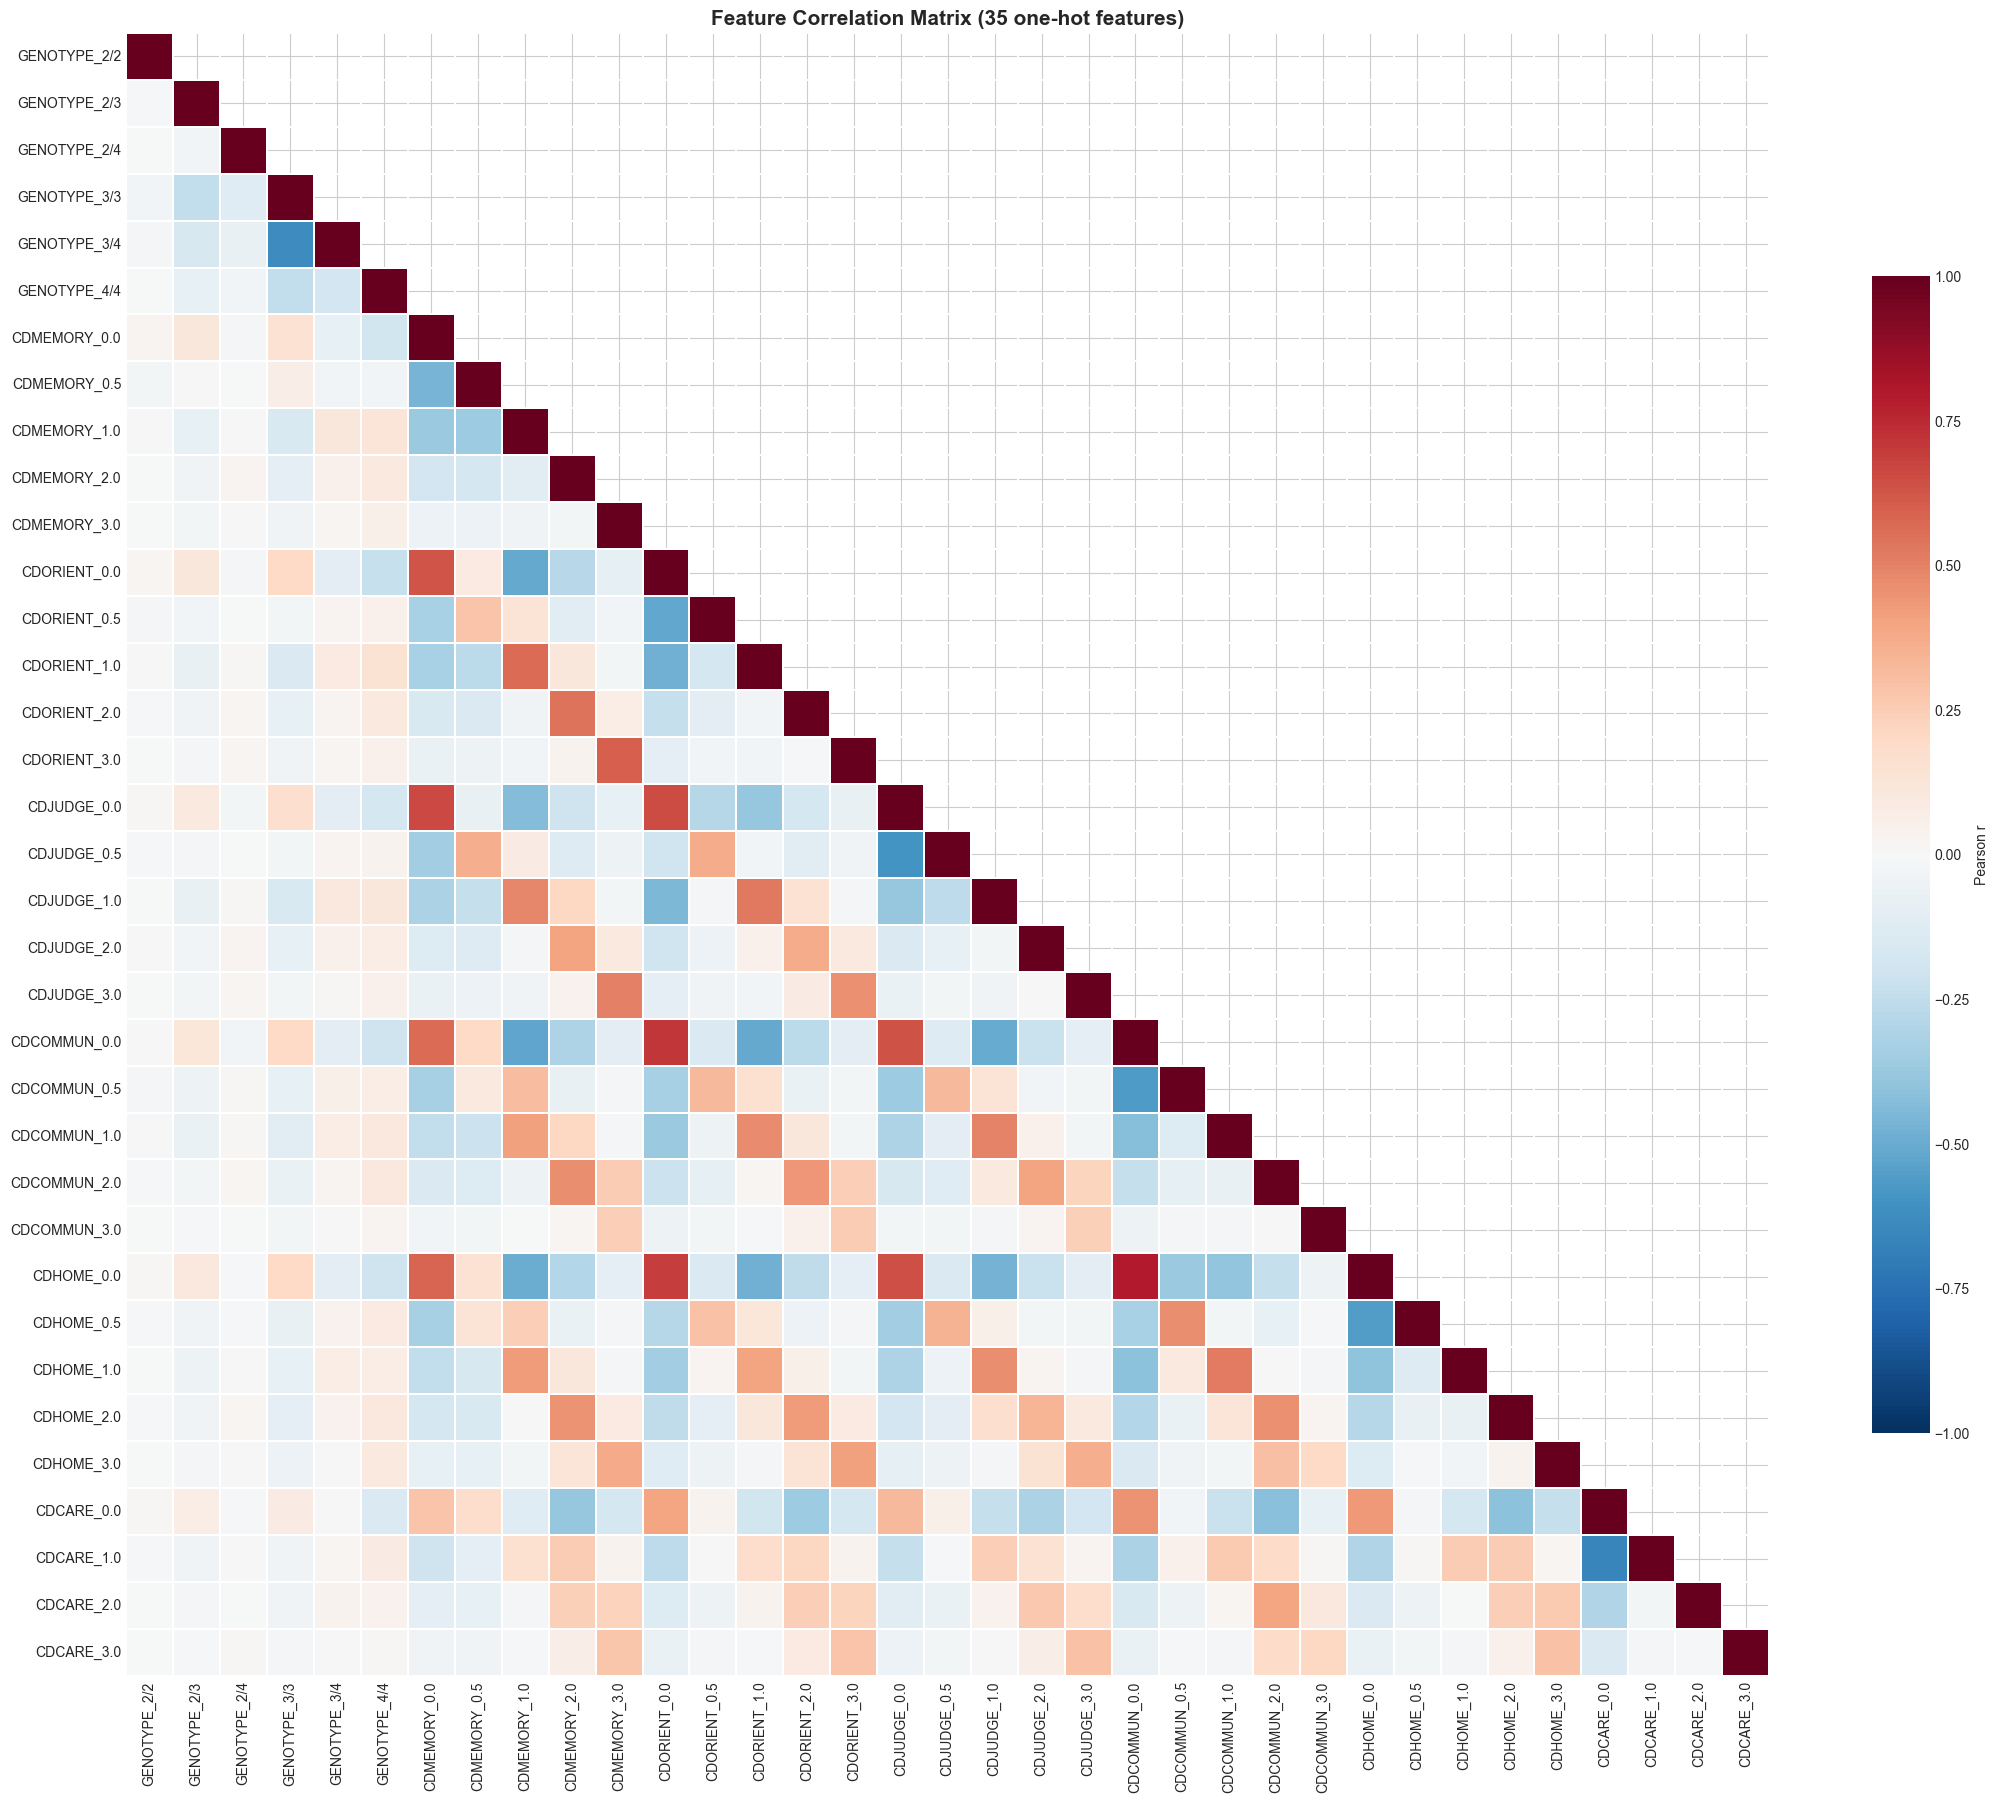

Highly correlated pairs (|r| > 0.7): 2
  CDCOMMUN_0.0         <-> CDHOME_0.0            r = +0.795
  CDORIENT_0.0         <-> CDCOMMUN_0.0          r = +0.719


In [13]:
feature_cols = [c for c in df.columns if c not in ['DIAGNOSIS', 'DIAGNOSIS_LABEL', 'GENOTYPE'] + list(CDR_DOMAINS.keys())]
corr = df[feature_cols].corr()

fig, ax = plt.subplots(figsize=(22, 18))
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            annot=False, square=True, linewidths=0.3,
            cbar_kws={'shrink': 0.7, 'label': 'Pearson r'}, ax=ax)
ax.set_title('Feature Correlation Matrix (35 one-hot features)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

high_corr = []
for i in range(len(corr)):
    for j in range(i+1, len(corr)):
        if abs(corr.iloc[i, j]) > 0.7:
            high_corr.append((corr.index[i], corr.columns[j], corr.iloc[i, j]))

print(f"Highly correlated pairs (|r| > 0.7): {len(high_corr)}")
for c1, c2, r in sorted(high_corr, key=lambda x: -abs(x[2])):
    print(f"  {c1:20s} <-> {c2:20s}  r = {r:+.3f}")

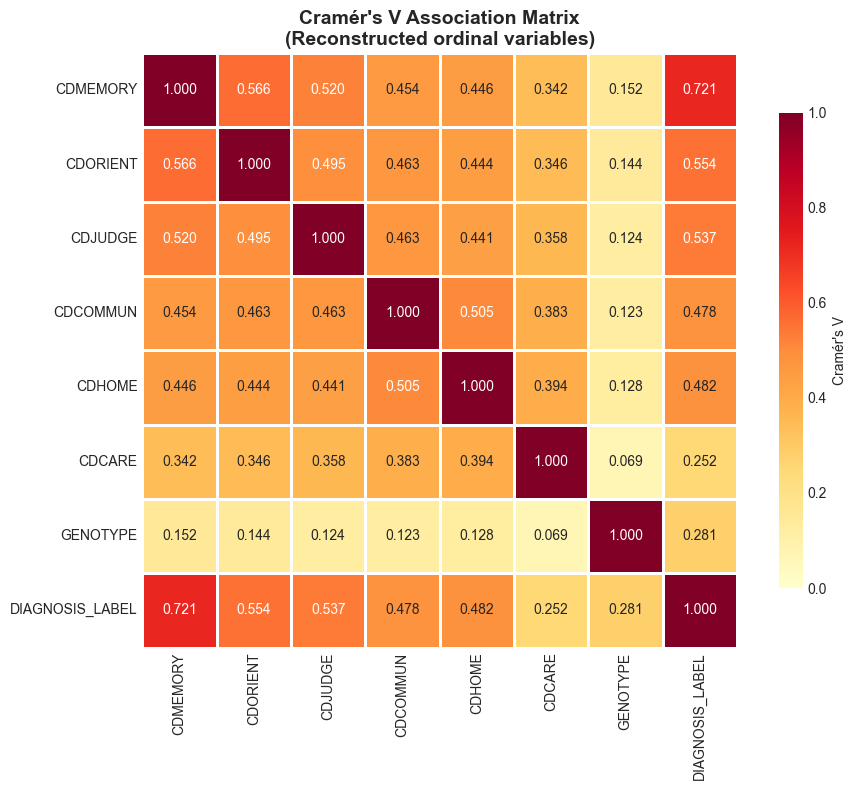

In [14]:
def cramers_v(x, y):
    ct = pd.crosstab(x, y)
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    min_dim = min(ct.shape[0], ct.shape[1]) - 1
    if min_dim == 0:
        return 0
    return np.sqrt(chi2 / (n * min_dim))

ordinal_cols = list(CDR_DOMAINS.keys()) + ['GENOTYPE', 'DIAGNOSIS_LABEL']
n = len(ordinal_cols)
cv_matrix = pd.DataFrame(np.zeros((n, n)), index=ordinal_cols, columns=ordinal_cols)

for i in range(n):
    for j in range(i, n):
        if i == j:
            cv_matrix.iloc[i, j] = 1.0
        else:
            v = cramers_v(df[ordinal_cols[i]], df[ordinal_cols[j]])
            cv_matrix.iloc[i, j] = v
            cv_matrix.iloc[j, i] = v

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cv_matrix.astype(float), annot=True, fmt='.3f', cmap='YlOrRd',
            vmin=0, vmax=1, square=True, linewidths=1, ax=ax,
            cbar_kws={'shrink': 0.8, 'label': "Cramér's V"})
ax.set_title("Cramér's V Association Matrix\n(Reconstructed ordinal variables)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Section 6: Feature-Target Relationships

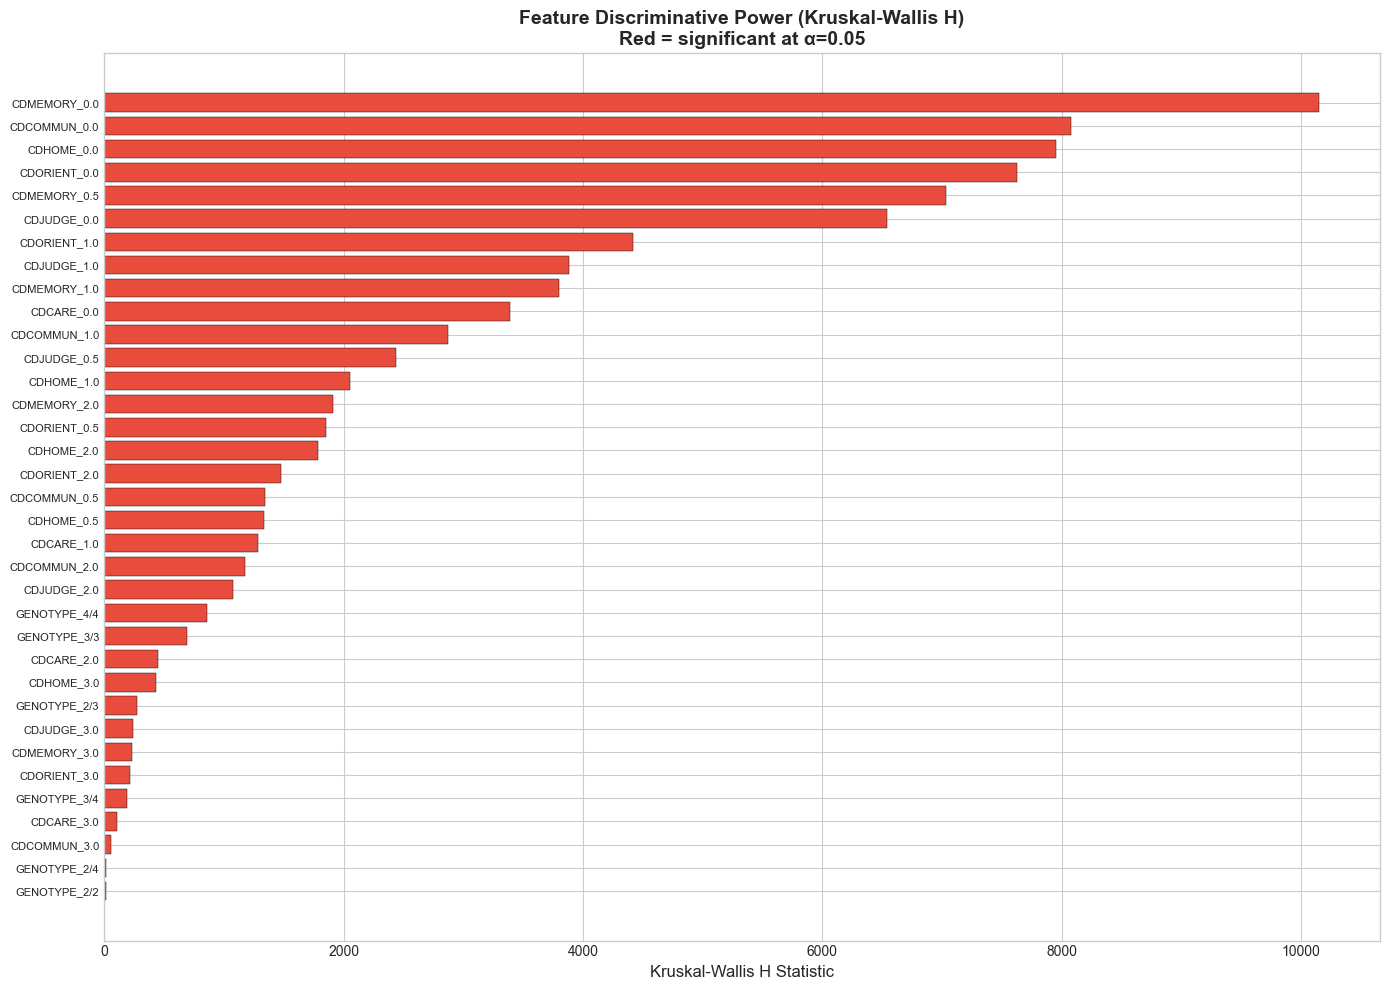

Significant features: 35 / 35

Top 10 discriminative features:
     Feature  H_statistic  p_value
CDMEMORY_0.0 10152.472729      0.0
CDCOMMUN_0.0  8075.959199      0.0
  CDHOME_0.0  7956.411273      0.0
CDORIENT_0.0  7630.296691      0.0
CDMEMORY_0.5  7034.402500      0.0
 CDJUDGE_0.0  6541.133851      0.0
CDORIENT_1.0  4418.109918      0.0
 CDJUDGE_1.0  3882.162988      0.0
CDMEMORY_1.0  3803.977573      0.0
  CDCARE_0.0  3393.745445      0.0


In [15]:
feature_cols = [c for c in df.columns if c not in ['DIAGNOSIS', 'DIAGNOSIS_LABEL', 'GENOTYPE'] + list(CDR_DOMAINS.keys())]

kw_results = []
for col in feature_cols:
    groups = [df.loc[df['DIAGNOSIS'] == d, col].values for d in [1.0, 2.0, 3.0]]
    stat, p = stats.kruskal(*groups)
    kw_results.append({'Feature': col, 'H_statistic': stat, 'p_value': p})

kw_df = pd.DataFrame(kw_results).sort_values('H_statistic', ascending=False).reset_index(drop=True)
kw_df['significant'] = kw_df['p_value'] < 0.05

fig, ax = plt.subplots(figsize=(14, 10))
colors = ['#e74c3c' if s else '#95a5a6' for s in kw_df['significant']]
ax.barh(range(len(kw_df)), kw_df['H_statistic'], color=colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(range(len(kw_df)))
ax.set_yticklabels(kw_df['Feature'], fontsize=8)
ax.set_xlabel('Kruskal-Wallis H Statistic', fontsize=12)
ax.set_title('Feature Discriminative Power (Kruskal-Wallis H)\nRed = significant at α=0.05', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Significant features: {kw_df['significant'].sum()} / {len(kw_df)}")
print(f"\nTop 10 discriminative features:")
print(kw_df.head(10)[['Feature', 'H_statistic', 'p_value']].to_string(index=False))

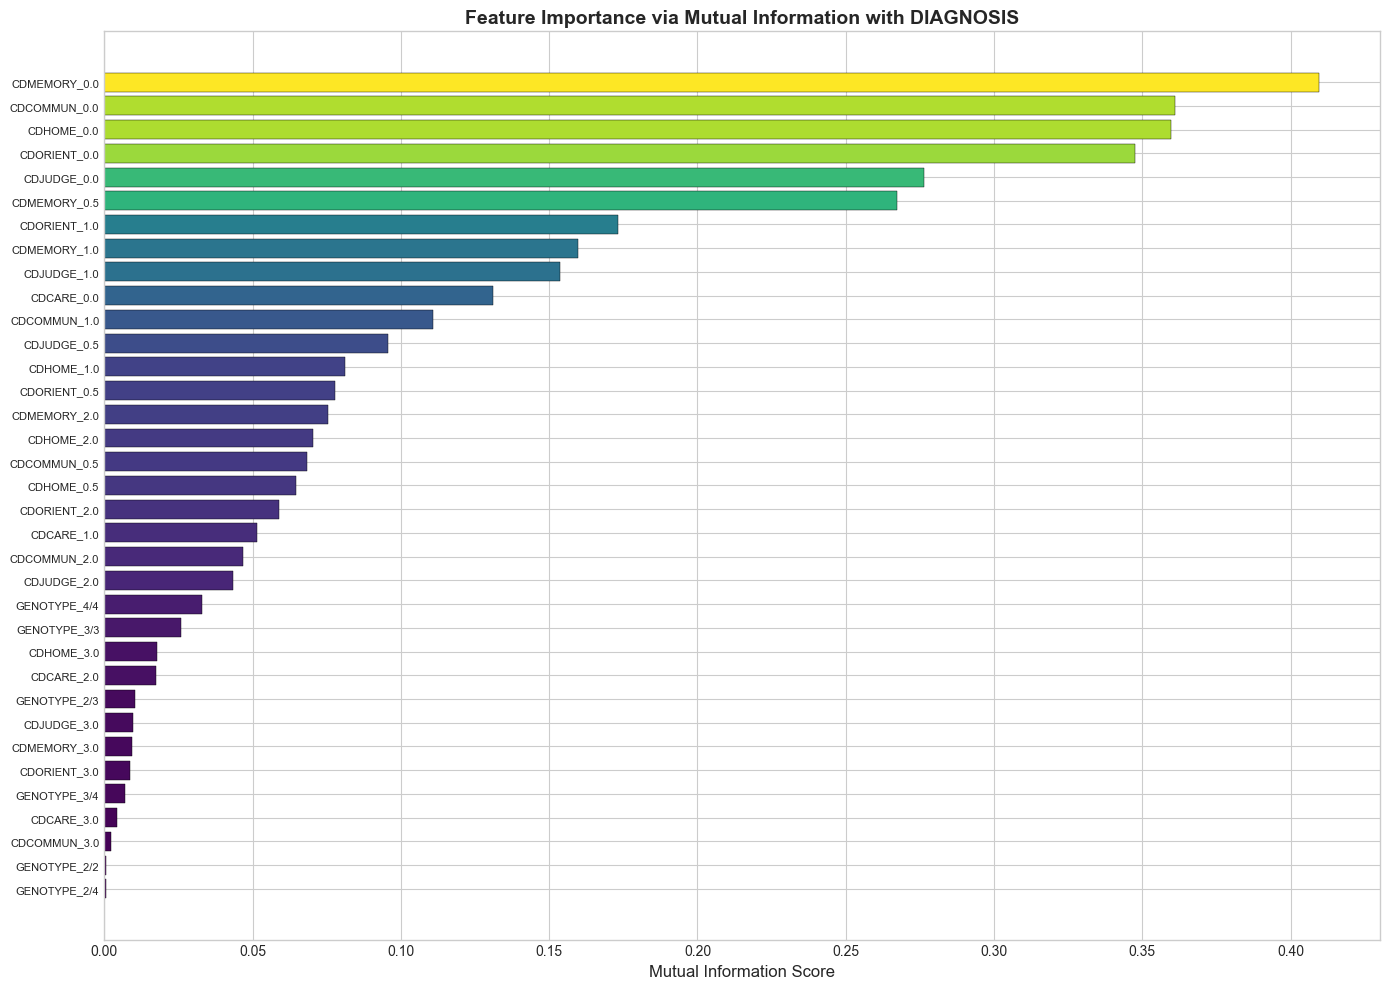

Top 10 features by Mutual Information:
     Feature  MI_Score
CDMEMORY_0.0  0.409638
CDCOMMUN_0.0  0.360912
  CDHOME_0.0  0.359516
CDORIENT_0.0  0.347572
 CDJUDGE_0.0  0.276385
CDMEMORY_0.5  0.267174
CDORIENT_1.0  0.173066
CDMEMORY_1.0  0.159583
 CDJUDGE_1.0  0.153582
  CDCARE_0.0  0.131050


In [16]:
feature_cols = [c for c in df.columns if c not in ['DIAGNOSIS', 'DIAGNOSIS_LABEL', 'GENOTYPE'] + list(CDR_DOMAINS.keys())]

X = df[feature_cols].values
y = df['DIAGNOSIS'].values

mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=42)
mi_df = pd.DataFrame({'Feature': feature_cols, 'MI_Score': mi_scores}).sort_values('MI_Score', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 10))
cmap = plt.cm.viridis
norm_vals = mi_df['MI_Score'] / mi_df['MI_Score'].max()
colors = [cmap(v) for v in norm_vals]

ax.barh(range(len(mi_df)), mi_df['MI_Score'], color=colors, edgecolor='black', linewidth=0.3)
ax.set_yticks(range(len(mi_df)))
ax.set_yticklabels(mi_df['Feature'], fontsize=8)
ax.set_xlabel('Mutual Information Score', fontsize=12)
ax.set_title('Feature Importance via Mutual Information with DIAGNOSIS', fontsize=14, fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Top 10 features by Mutual Information:")
print(mi_df.head(10).to_string(index=False))

## Section 7: Multi-Feature Interaction Patterns

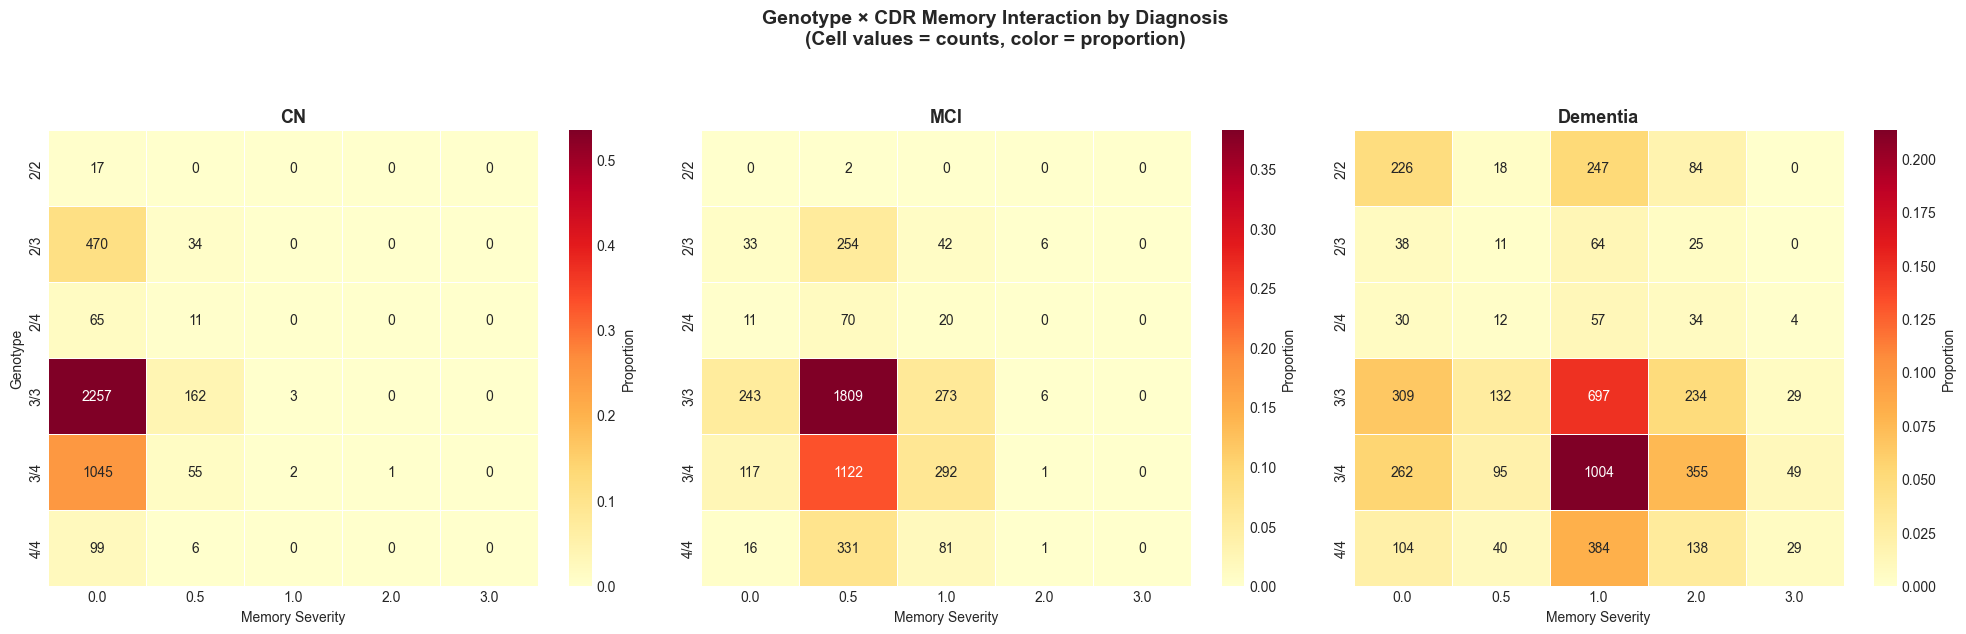

In [17]:
diag_order = ['CN', 'MCI', 'Dementia']
geno_order = ['2/2', '2/3', '2/4', '3/3', '3/4', '4/4']
mem_levels = sorted(df['CDMEMORY'].unique())

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, diag in enumerate(diag_order):
    sub = df[df['DIAGNOSIS_LABEL'] == diag]
    ct = pd.crosstab(sub['GENOTYPE'], sub['CDMEMORY'])
    ct = ct.reindex(index=geno_order, columns=mem_levels, fill_value=0)
    ct_norm = ct.div(ct.sum().sum())

    sns.heatmap(ct_norm, annot=ct.values, fmt='d', cmap='YlOrRd', ax=axes[idx],
                linewidths=0.5, cbar_kws={'label': 'Proportion'})
    axes[idx].set_title(f'{diag}', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('Memory Severity')
    axes[idx].set_ylabel('Genotype' if idx == 0 else '')

plt.suptitle('Genotype × CDR Memory Interaction by Diagnosis\n(Cell values = counts, color = proportion)',
             fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

Top 10 most common CDR severity profiles per diagnosis class:

--- CN (n=4,227) ---
  0.0-0.0-0.0-0.0-0.0-0.0                   n= 3638  ( 86.1%)
  0.0-0.0-0.5-0.0-0.0-0.0                   n=  218  (  5.2%)
  0.5-0.0-0.0-0.0-0.0-0.0                   n=  132  (  3.1%)
  0.5-0.0-0.5-0.0-0.0-0.0                   n=   49  (  1.2%)
  0.0-0.5-0.0-0.0-0.0-0.0                   n=   37  (  0.9%)
  0.0-0.0-0.0-0.0-0.5-0.0                   n=   25  (  0.6%)
  0.5-0.5-0.0-0.0-0.0-0.0                   n=   17  (  0.4%)
  0.5-0.5-0.5-0.0-0.0-0.0                   n=   14  (  0.3%)
  0.5-0.0-0.0-0.0-0.5-0.0                   n=   11  (  0.3%)
  0.5-0.0-0.5-0.0-0.5-0.0                   n=    9  (  0.2%)

--- MCI (n=4,730) ---
  0.5-0.0-0.0-0.0-0.0-0.0                   n=  906  ( 19.2%)
  0.5-0.0-0.5-0.0-0.0-0.0                   n=  611  ( 12.9%)
  0.5-0.5-0.5-0.0-0.0-0.0                   n=  363  (  7.7%)
  0.0-0.0-0.0-0.0-0.0-0.0                   n=  253  (  5.3%)
  0.5-0.5-0.5-0.5-0.5-0.0

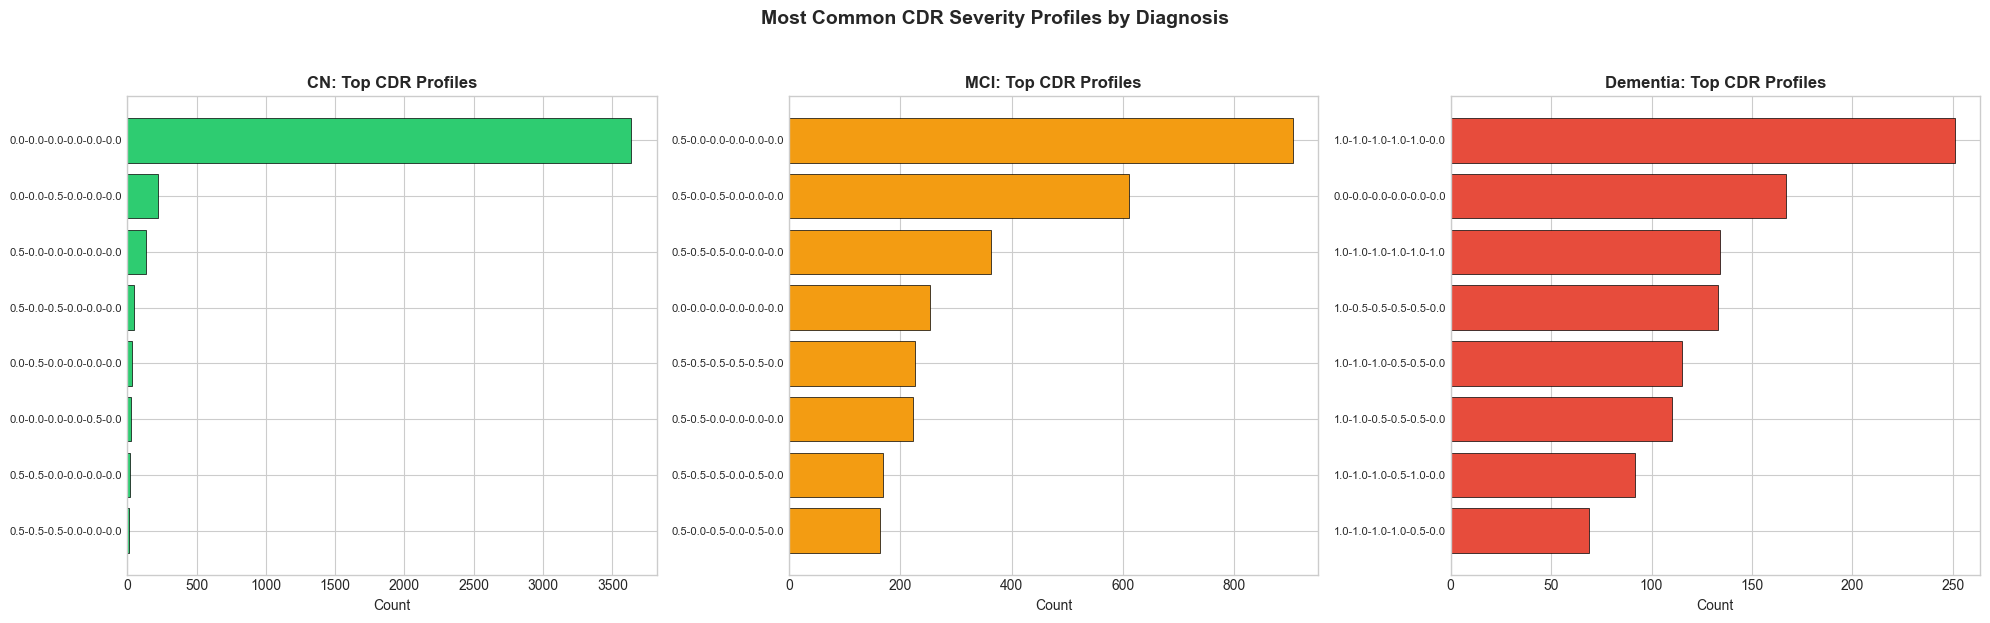

In [18]:
domains = list(CDR_DOMAINS.keys())
diag_order = ['CN', 'MCI', 'Dementia']

df['CDR_PROFILE'] = df[domains].astype(str).agg('-'.join, axis=1)

print("Top 10 most common CDR severity profiles per diagnosis class:\n")
for diag in diag_order:
    sub = df[df['DIAGNOSIS_LABEL'] == diag]
    top = sub['CDR_PROFILE'].value_counts().head(10)
    print(f"--- {diag} (n={len(sub):,}) ---")
    for profile, count in top.items():
        pct = count / len(sub) * 100
        print(f"  {profile:40s}  n={count:5d}  ({pct:5.1f}%)")
    print()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))
for idx, diag in enumerate(diag_order):
    sub = df[df['DIAGNOSIS_LABEL'] == diag]
    top5 = sub['CDR_PROFILE'].value_counts().head(8)
    axes[idx].barh(range(len(top5)), top5.values, color=DIAG_COLORS[diag], edgecolor='black', linewidth=0.5)
    axes[idx].set_yticks(range(len(top5)))
    axes[idx].set_yticklabels(top5.index, fontsize=8)
    axes[idx].set_xlabel('Count')
    axes[idx].set_title(f'{diag}: Top CDR Profiles', fontsize=12, fontweight='bold')
    axes[idx].invert_yaxis()

plt.suptitle('Most Common CDR Severity Profiles by Diagnosis', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

## Section 8: Dimensionality Reduction Visualization

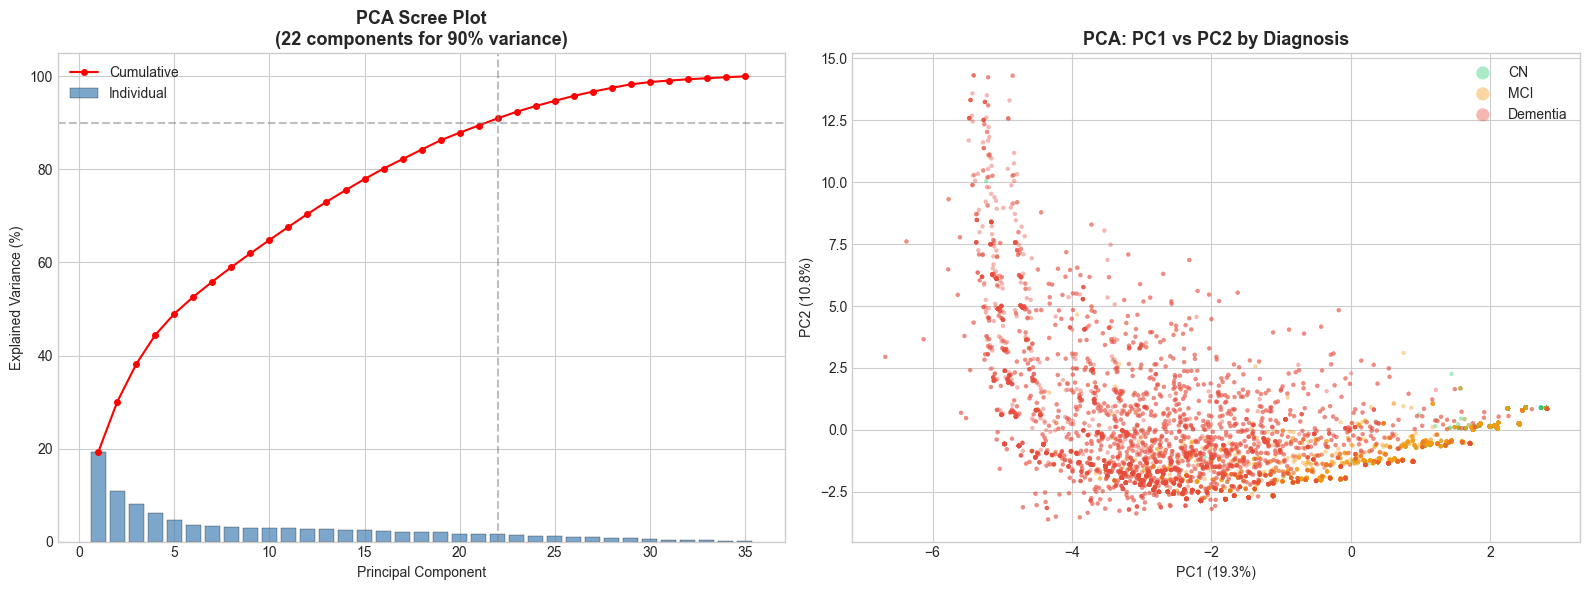

In [19]:
feature_cols = [c for c in df.columns if c not in ['DIAGNOSIS', 'DIAGNOSIS_LABEL', 'GENOTYPE', 'CDR_PROFILE'] + list(CDR_DOMAINS.keys())]

X = df[feature_cols].values
y_labels = df['DIAGNOSIS_LABEL'].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(random_state=42)
X_pca = pca.fit_transform(X_scaled)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
axes[0].bar(range(1, len(pca.explained_variance_ratio_)+1), pca.explained_variance_ratio_*100,
            color='steelblue', edgecolor='black', linewidth=0.3, alpha=0.7, label='Individual')
axes[0].plot(range(1, len(cumvar)+1), cumvar, 'ro-', markersize=4, label='Cumulative')
axes[0].axhline(y=90, color='gray', linestyle='--', alpha=0.5)
n_90 = np.argmax(cumvar >= 90) + 1
axes[0].axvline(x=n_90, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Explained Variance (%)')
axes[0].set_title(f'PCA Scree Plot\n({n_90} components for 90% variance)', fontsize=13, fontweight='bold')
axes[0].legend()

diag_order = ['CN', 'MCI', 'Dementia']
for diag in diag_order:
    mask = y_labels == diag
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], c=DIAG_COLORS[diag],
                    label=diag, alpha=0.4, s=10, edgecolors='none')
axes[1].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
axes[1].set_title('PCA: PC1 vs PC2 by Diagnosis', fontsize=13, fontweight='bold')
axes[1].legend(markerscale=3)

plt.tight_layout()
plt.show()

In [20]:
np.random.seed(42)
sample_idx = np.random.choice(len(X_scaled), size=min(5000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_idx]
y_sample = y_labels[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=50, n_iter=1000)
X_tsne = tsne.fit_transform(X_sample)

fig, ax = plt.subplots(figsize=(10, 8))
for diag in ['CN', 'MCI', 'Dementia']:
    mask = y_sample == diag
    ax.scatter(X_tsne[mask, 0], X_tsne[mask, 1], c=DIAG_COLORS[diag],
               label=diag, alpha=0.5, s=15, edgecolors='none')
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title(f't-SNE Visualization (n={len(X_sample):,} sampled)', fontsize=14, fontweight='bold')
ax.legend(markerscale=3, fontsize=11)
plt.tight_layout()
plt.show()

TypeError: TSNE.__init__() got an unexpected keyword argument 'n_iter'

## Section 9: Summary and Key Findings

### EDA Key Findings

**1. Data Quality**
- Dataset: 13,668 rows × 36 columns (all one-hot encoded features + DIAGNOSIS target)
- No missing values; all feature values are binary (0/1)
- Mutual exclusivity verified within each one-hot group (GENOTYPE, 6 CDR domains)

**2. Class Balance**
- The dataset is balanced across three diagnosis classes: CN (Cognitively Normal), MCI (Mild Cognitive Impairment), Dementia
- Balance ratio (min/max class count) should be close to 1.0

**3. APOE Genotype Insights**
- Most common genotypes: 3/3 (most frequent) and 3/4; rare genotypes: 2/2, 2/4, 4/4
- Chi-squared test confirms significant association between genotype and diagnosis
- e4-carrying genotypes (3/4, 4/4) are expected to be enriched in Dementia relative to CN

**4. CDR Domain Patterns**
- CDR Memory is the most discriminative domain — severity increases sharply from CN → MCI → Dementia
- CDR Care shows the least granularity (no 0.5 level)
- Radar plot reveals that Dementia patients have uniformly elevated severity across all 6 domains, while MCI patients show selectively elevated Memory scores

**5. Feature Correlations**
- Strong negative correlations exist within one-hot groups (e.g., CDMEMORY_0.0 vs CDMEMORY_1.0) — this is expected and inherent to the encoding
- Cramér's V matrix on reconstructed ordinal variables provides cleaner insight: CDR domains are moderately-to-strongly associated with each other and with DIAGNOSIS
- GENOTYPE has a weaker but significant association with DIAGNOSIS

**6. Feature Importance**
- CDR Memory severity levels dominate both Kruskal-Wallis and Mutual Information rankings
- GENOTYPE features contribute less discriminative power than clinical CDR features
- CDR Home and CDR Judgment features also rank highly

**7. Interaction Patterns**
- Genotype × Memory interaction heatmaps show that e4 carriers with higher memory severity are disproportionately represented in Dementia
- CN patients cluster around a single CDR profile (all zeros/low severity), while Dementia profiles are more diverse

**8. Dimensionality Reduction**
- PCA shows significant explained variance concentration in the first few components
- t-SNE reveals partial but not perfect separation of the three classes, suggesting overlap between CN/MCI and MCI/Dementia boundaries

### Modeling Recommendations
- **Feature engineering**: Consider using the reconstructed ordinal severity scores (0–3) instead of one-hot encoding to reduce dimensionality from 35 to 7 features
- **Class overlap**: The MCI class likely overlaps with both CN and Dementia — consider ordinal classification or hierarchical approaches
- **Genotype interaction features**: Creating genotype × CDR severity interaction terms may improve model performance
- **Model selection**: Tree-based models (Random Forest, XGBoost) naturally handle the categorical nature of these features

In [22]:
ordinal_df = pd.DataFrame()

for domain, cols in CDR_DOMAINS.items():
    valid = [c for c in cols if c in df.columns]
    levels = [float(c.split('_')[-1]) for c in valid]
    row_sums = df[valid].sum(axis=1)
    ordinal_df[domain] = np.where(
        row_sums == 0,
        np.nan,
        np.array(levels)[df[valid].values.argmax(axis=1)]
    )

geno_labels = [c.replace('GENOTYPE_', '') for c in GENOTYPE_COLS]
row_sums = df[GENOTYPE_COLS].sum(axis=1)
geno_decoded = pd.array(np.array(geno_labels)[df[GENOTYPE_COLS].values.argmax(axis=1)], dtype="string")
geno_decoded[row_sums == 0] = pd.NA
ordinal_df['GENOTYPE'] = geno_decoded

ordinal_df['DIAGNOSIS'] = df['DIAGNOSIS']

out_path = '../data/balanced_diagnosis_ordinal.csv'
ordinal_df.to_csv(out_path, index=False)

print(f"Shape: {ordinal_df.shape}")
print(f"Columns: {ordinal_df.columns.tolist()}")
print(f"\nNull counts:\n{ordinal_df.isnull().sum()}")
print(f"\nSaved to: {out_path}")
ordinal_df.head(10)

Shape: (13668, 8)
Columns: ['CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN', 'CDHOME', 'CDCARE', 'GENOTYPE', 'DIAGNOSIS']

Null counts:
CDMEMORY     826
CDORIENT     730
CDJUDGE      596
CDCOMMUN     998
CDHOME       932
CDCARE       744
GENOTYPE     564
DIAGNOSIS      0
dtype: int64

Saved to: ../data/balanced_diagnosis_ordinal.csv


,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,GENOTYPE,DIAGNOSIS
0,1.0,0.5,0.5,0.5,0.5,0.0,3/4,3.0
1,3.0,0.5,NaN,2.0,2.0,NaN,4/4,3.0
2,1.0,NaN,NaN,0.5,0.5,NaN,<NA>,3.0
3,1.0,1.0,1.0,0.5,NaN,0.0,<NA>,3.0
4,1.0,1.0,0.5,NaN,0.5,NaN,4/4,3.0
5,0.5,NaN,0.5,NaN,0.5,0.0,<NA>,3.0
6,NaN,0.0,0.0,0.0,3.0,NaN,<NA>,3.0
7,NaN,NaN,NaN,2.0,NaN,NaN,<NA>,3.0
8,NaN,NaN,NaN,NaN,1.0,NaN,3/4,3.0
9,1.0,NaN,0.5,0.5,NaN,0.0,3/3,3.0


In [23]:
print("=== Missing Value Analysis ===")
print(f"Total rows: {len(ordinal_df)}")
print(f"\nNulls per column:")
print(ordinal_df.isnull().sum().to_string())

rows_any_na = ordinal_df.isnull().any(axis=1).sum()
rows_all_complete = len(ordinal_df) - rows_any_na
print(f"\nRows with at least 1 NA: {rows_any_na} ({rows_any_na/len(ordinal_df)*100:.1f}%)")
print(f"Fully complete rows:     {rows_all_complete} ({rows_all_complete/len(ordinal_df)*100:.1f}%)")

print(f"\nNA count per row distribution:")
na_per_row = ordinal_df.isnull().sum(axis=1)
print(na_per_row.value_counts().sort_index().to_string())

=== Missing Value Analysis ===
Total rows: 13668

Nulls per column:
CDMEMORY     826
CDORIENT     730
CDJUDGE      596
CDCOMMUN     998
CDHOME       932
CDCARE       744
GENOTYPE     564
DIAGNOSIS      0

Rows with at least 1 NA: 2094 (15.3%)
Fully complete rows:     11574 (84.7%)

NA count per row distribution:
0    11574
1      498
2      604
3      488
4      348
5      110
6       44
7        2


In [24]:
ordinal_clean = ordinal_df.dropna()

out_path = '../data/balanced_diagnosis_ordinal.csv'
ordinal_clean.to_csv(out_path, index=False)

print(f"Before: {len(ordinal_df)} rows")
print(f"After dropping NAs: {len(ordinal_clean)} rows ({len(ordinal_clean)/len(ordinal_df)*100:.1f}% retained)")
print(f"\nDiagnosis distribution after cleaning:")
print(ordinal_clean['DIAGNOSIS'].map(DIAGNOSIS_MAP).value_counts().to_string())
print(f"\nBalance ratio: {ordinal_clean['DIAGNOSIS'].value_counts().min() / ordinal_clean['DIAGNOSIS'].value_counts().max():.3f}")
print(f"\nSaved to: {out_path}")
ordinal_clean.head(10)

Before: 13668 rows
After dropping NAs: 11574 rows (84.7% retained)

Diagnosis distribution after cleaning:
DIAGNOSIS
MCI         4730
CN          4227
Dementia    2617

Balance ratio: 0.553

Saved to: ../data/balanced_diagnosis_ordinal.csv


,CDMEMORY,CDORIENT,CDJUDGE,CDCOMMUN,CDHOME,CDCARE,GENOTYPE,DIAGNOSIS
0,1.0,0.5,0.5,0.5,0.5,0.0,3/4,3.0
14,1.0,0.5,0.5,0.5,0.5,0.0,4/4,3.0
16,1.0,1.0,1.0,0.5,0.5,0.0,2/3,3.0
18,1.0,1.0,1.0,0.5,0.5,0.0,3/3,3.0
20,1.0,0.5,0.5,0.5,0.5,0.0,3/4,3.0
23,1.0,1.0,1.0,0.5,0.5,0.0,3/3,3.0
43,0.0,2.0,0.0,1.0,2.0,0.0,3/4,3.0
45,0.0,0.0,0.5,0.5,1.0,0.0,3/3,3.0
47,1.0,1.0,1.0,0.5,0.5,0.0,3/4,3.0
60,1.0,1.0,0.5,0.5,0.5,0.0,3/3,3.0


## Synthetic Data Generation: SMOTE-NC vs CTGAN Comparison

In [25]:
from imblearn.over_sampling import SMOTENC
from sdv.single_table import CTGANSynthesizer
from sdv.metadata import Metadata
from sklearn.preprocessing import LabelEncoder
import time

ordinal_clean = pd.read_csv('../data/balanced_diagnosis_ordinal.csv')
target_count = ordinal_clean['DIAGNOSIS'].value_counts().max()
dementia_count = (ordinal_clean['DIAGNOSIS'] == 3.0).sum()
deficit = target_count - dementia_count

print(f"Current class distribution:")
print(ordinal_clean['DIAGNOSIS'].value_counts().sort_index().to_string())
print(f"\nTarget count per class: {target_count}")
print(f"Dementia samples needed: {deficit}")

Current class distribution:
DIAGNOSIS
1.0    4227
2.0    4730
3.0    2617

Target count per class: 4730
Dementia samples needed: 2113


### Method 1: SMOTE-NC

In [26]:
le = LabelEncoder()
ordinal_work = ordinal_clean.copy()
ordinal_work['GENOTYPE_ENC'] = le.fit_transform(ordinal_work['GENOTYPE'])

feature_cols = ['CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN', 'CDHOME', 'CDCARE', 'GENOTYPE_ENC']
X = ordinal_work[feature_cols].values
y = ordinal_work['DIAGNOSIS'].values

categorical_idx = [6]  # GENOTYPE_ENC is the only categorical feature

start = time.time()
smote_nc = SMOTENC(
    categorical_features=categorical_idx,
    sampling_strategy={3.0: target_count},
    random_state=42,
    k_neighbors=5
)
X_smote, y_smote = smote_nc.fit_resample(X, y)
smote_time = time.time() - start

VALID_CDR_LEVELS = np.array([0.0, 0.5, 1.0, 2.0, 3.0])
X_smote_fixed = X_smote.copy()
for col_idx in range(6):
    diffs = np.abs(X_smote_fixed[:, col_idx][:, None] - VALID_CDR_LEVELS[None, :])
    X_smote_fixed[:, col_idx] = VALID_CDR_LEVELS[diffs.argmin(axis=1)]

smote_df = pd.DataFrame(X_smote_fixed, columns=feature_cols)
smote_df['GENOTYPE'] = le.inverse_transform(smote_df['GENOTYPE_ENC'].astype(int))
smote_df['DIAGNOSIS'] = y_smote
smote_df = smote_df.drop(columns=['GENOTYPE_ENC'])
smote_df = smote_df[['CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN', 'CDHOME', 'CDCARE', 'GENOTYPE', 'DIAGNOSIS']]

smote_synthetic = smote_df[len(ordinal_clean):]

print(f"SMOTE-NC completed in {smote_time:.2f}s")
print(f"Total dataset: {len(smote_df)} rows")
print(f"Synthetic Dementia samples generated: {len(smote_synthetic)}")
print(f"\nClass distribution after SMOTE-NC:")
print(smote_df['DIAGNOSIS'].value_counts().sort_index().to_string())

SMOTE-NC completed in 0.13s
Total dataset: 13687 rows
Synthetic Dementia samples generated: 2113

Class distribution after SMOTE-NC:
DIAGNOSIS
1.0    4227
2.0    4730
3.0    4730


### Method 2: CTGAN

In [27]:
dementia_real = ordinal_clean[ordinal_clean['DIAGNOSIS'] == 3.0].copy()

metadata = Metadata.detect_from_dataframe(dementia_real)
metadata.update_column('CDMEMORY', sdtype='numerical')
metadata.update_column('CDORIENT', sdtype='numerical')
metadata.update_column('CDJUDGE', sdtype='numerical')
metadata.update_column('CDCOMMUN', sdtype='numerical')
metadata.update_column('CDHOME', sdtype='numerical')
metadata.update_column('CDCARE', sdtype='numerical')
metadata.update_column('GENOTYPE', sdtype='categorical')
metadata.update_column('DIAGNOSIS', sdtype='categorical')

start = time.time()
ctgan = CTGANSynthesizer(
    metadata,
    epochs=300,
    batch_size=500,
    verbose=True
)
ctgan.fit(dementia_real)
ctgan_time = time.time() - start

ctgan_synthetic = ctgan.sample(num_rows=deficit)

for col in ['CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN', 'CDHOME', 'CDCARE']:
    diffs = np.abs(ctgan_synthetic[col].values[:, None] - VALID_CDR_LEVELS[None, :])
    ctgan_synthetic[col] = VALID_CDR_LEVELS[diffs.argmin(axis=1)]

ctgan_synthetic['DIAGNOSIS'] = 3.0

ctgan_df = pd.concat([ordinal_clean, ctgan_synthetic], ignore_index=True)

print(f"CTGAN completed in {ctgan_time:.2f}s")
print(f"Total dataset: {len(ctgan_df)} rows")
print(f"Synthetic Dementia samples generated: {len(ctgan_synthetic)}")
print(f"\nClass distribution after CTGAN:")
print(ctgan_df['DIAGNOSIS'].value_counts().sort_index().to_string())

/Users/tarubprakash/Desktop/tarun/temp btp/.venv/lib/python3.11/site-packages/sdv/single_table/base.py:134: UserWarning:

We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.

Gen. (+00.00) | Discrim. (+00.00):   0%|          | 0/300 [00:00<?, ?it/s]Gen. (-00.79) | Discrim. (-00.10):  42%|████▏     | 126/300 [00:20<00:20,  8.31it/s]Gen. (+00.21) | Discrim. (-00.30):  76%|███████▌  | 227/300 [00:33<00:08,  8.53it/s]Gen. (-00.23) | Discrim. (-00.07): 100%|██████████| 300/300 [00:42<00:00,  7.09it/s]


CTGAN completed in 53.59s
Total dataset: 13687 rows
Synthetic Dementia samples generated: 2113

Class distribution after CTGAN:
DIAGNOSIS
1.0    4227
2.0    4730
3.0    4730


### Comparison: Real vs SMOTE-NC vs CTGAN

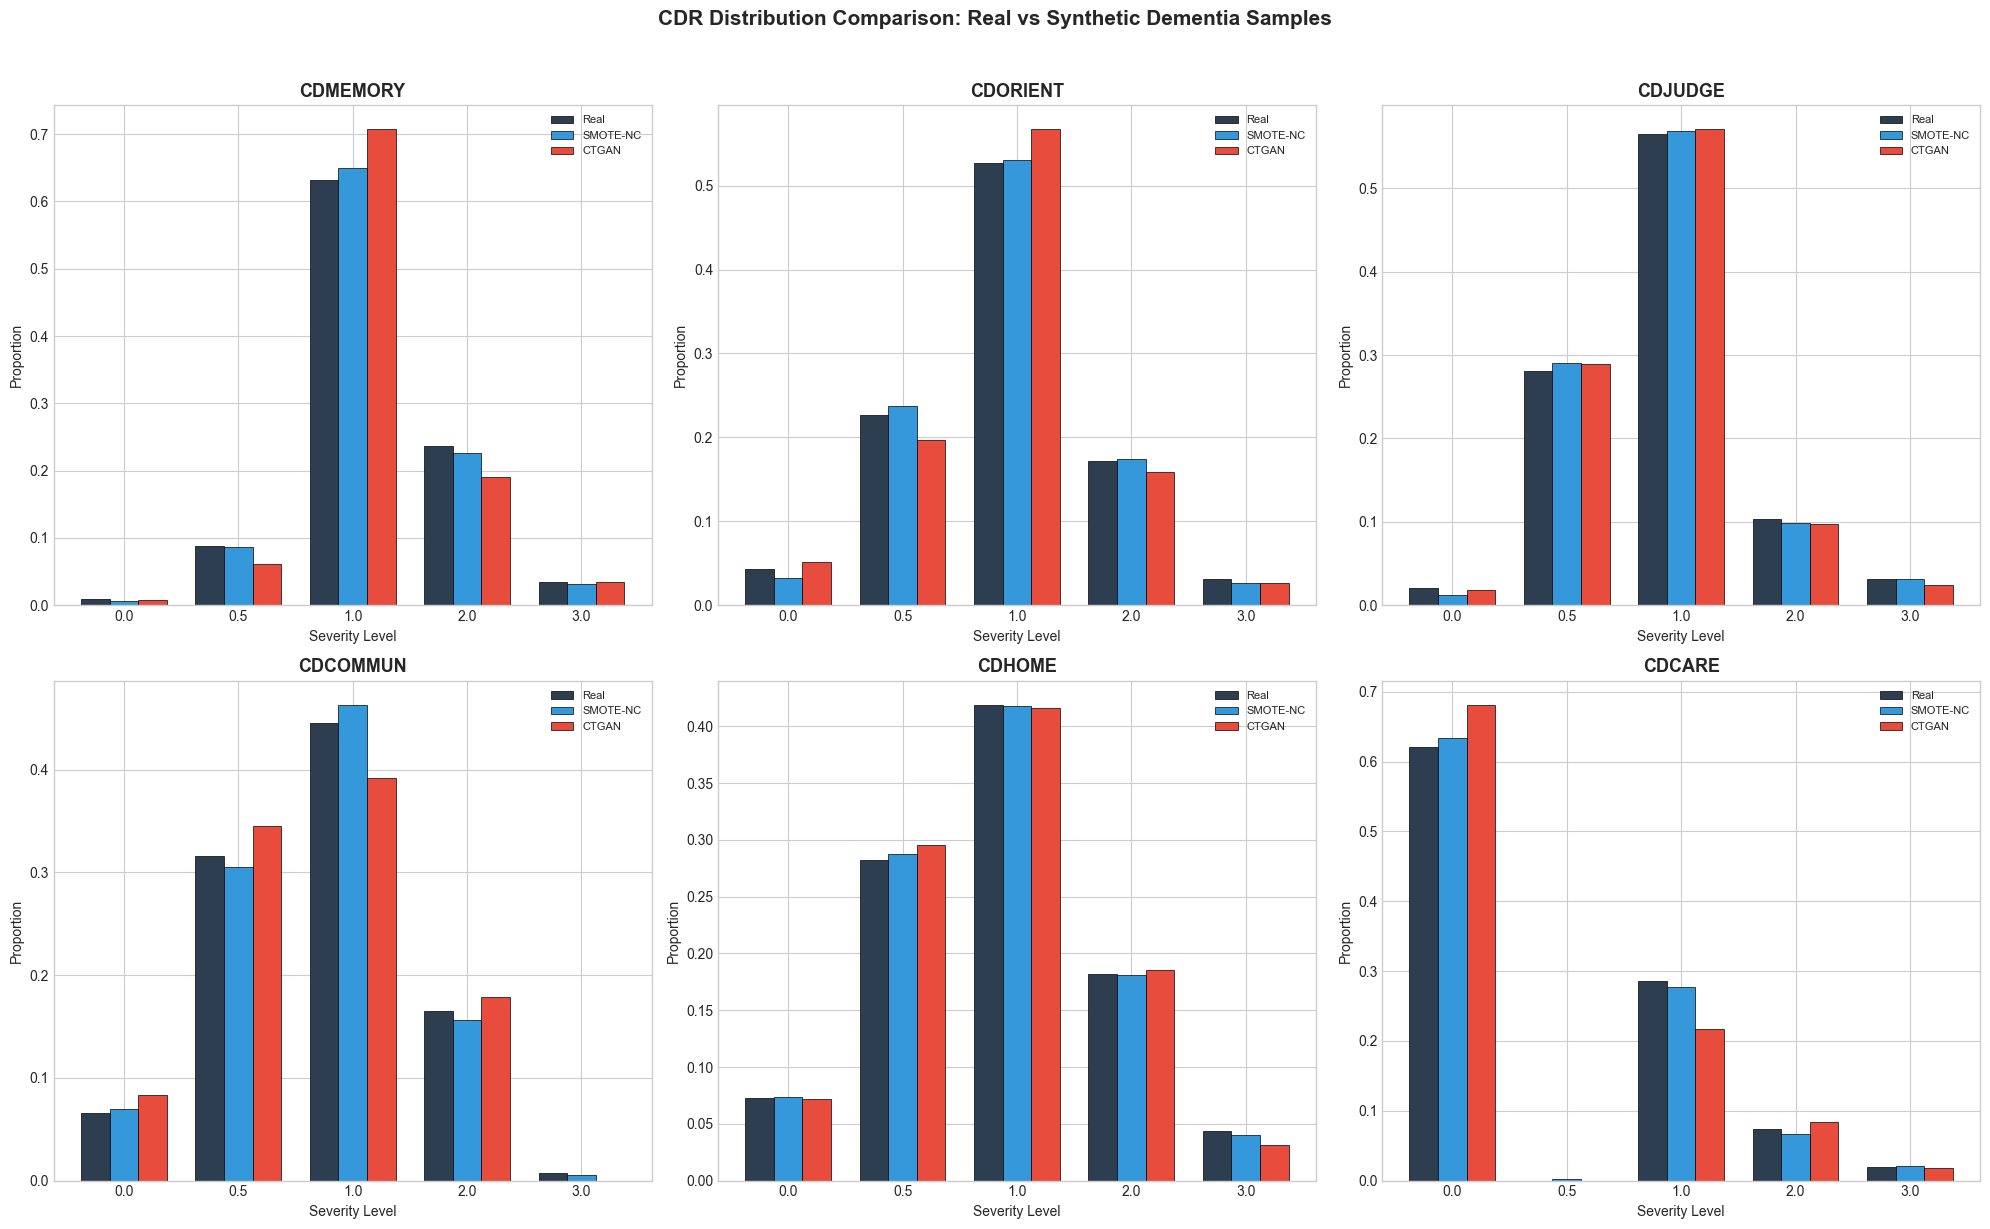

In [28]:
cdr_cols = ['CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN', 'CDHOME', 'CDCARE']

fig, axes = plt.subplots(2, 3, figsize=(20, 12))
axes = axes.flatten()

for i, col in enumerate(cdr_cols):
    real_vc = dementia_real[col].value_counts(normalize=True).reindex(VALID_CDR_LEVELS, fill_value=0)
    smote_vc = smote_synthetic[col].value_counts(normalize=True).reindex(VALID_CDR_LEVELS, fill_value=0)
    ctgan_vc = ctgan_synthetic[col].value_counts(normalize=True).reindex(VALID_CDR_LEVELS, fill_value=0)

    x = np.arange(len(VALID_CDR_LEVELS))
    w = 0.25
    axes[i].bar(x - w, real_vc.values, w, label='Real', color='#2c3e50', edgecolor='black', linewidth=0.5)
    axes[i].bar(x,     smote_vc.values, w, label='SMOTE-NC', color='#3498db', edgecolor='black', linewidth=0.5)
    axes[i].bar(x + w, ctgan_vc.values, w, label='CTGAN', color='#e74c3c', edgecolor='black', linewidth=0.5)

    axes[i].set_xticks(x)
    axes[i].set_xticklabels([str(v) for v in VALID_CDR_LEVELS])
    axes[i].set_title(f'{col}', fontsize=13, fontweight='bold')
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel('Severity Level')
    axes[i].legend(fontsize=8)

plt.suptitle('CDR Distribution Comparison: Real vs Synthetic Dementia Samples', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

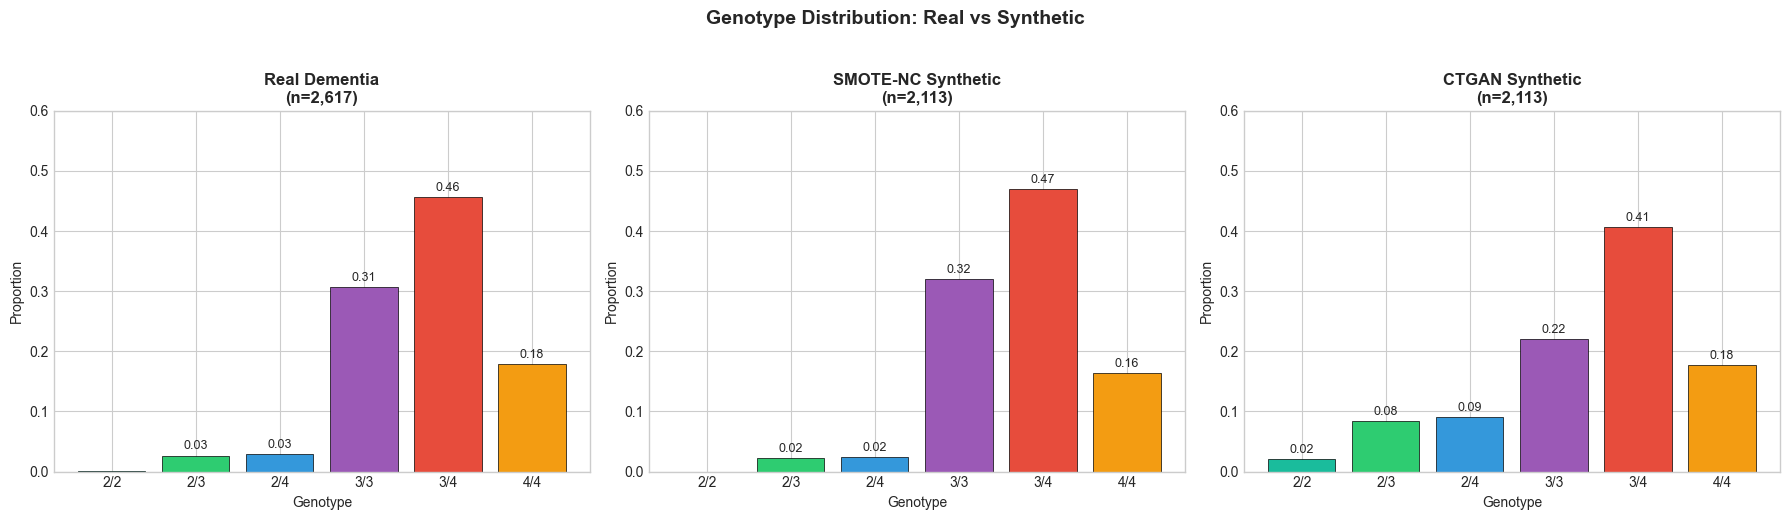

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (label, data) in enumerate([
    ('Real Dementia', dementia_real),
    ('SMOTE-NC Synthetic', smote_synthetic),
    ('CTGAN Synthetic', ctgan_synthetic)
]):
    geno_vc = data['GENOTYPE'].value_counts(normalize=True).reindex(
        ['2/2', '2/3', '2/4', '3/3', '3/4', '4/4'], fill_value=0)
    axes[idx].bar(geno_vc.index, geno_vc.values, color=['#1abc9c','#2ecc71','#3498db','#9b59b6','#e74c3c','#f39c12'],
                  edgecolor='black', linewidth=0.5)
    axes[idx].set_title(f'{label}\n(n={len(data):,})', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Proportion')
    axes[idx].set_xlabel('Genotype')
    axes[idx].set_ylim(0, 0.6)
    for bar, val in zip(axes[idx].patches, geno_vc.values):
        if val > 0.01:
            axes[idx].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                           f'{val:.2f}', ha='center', fontsize=9)

plt.suptitle('Genotype Distribution: Real vs Synthetic', fontsize=14, fontweight='bold', y=1.03)
plt.tight_layout()
plt.show()

In [30]:
print("=== Statistical Fidelity: Mean & Std Comparison ===\n")
cdr_cols = ['CDMEMORY', 'CDORIENT', 'CDJUDGE', 'CDCOMMUN', 'CDHOME', 'CDCARE']

stats_rows = []
for col in cdr_cols:
    stats_rows.append({
        'Feature': col,
        'Real_mean': dementia_real[col].mean(),
        'SMOTE_mean': smote_synthetic[col].mean(),
        'CTGAN_mean': ctgan_synthetic[col].mean(),
        'Real_std': dementia_real[col].std(),
        'SMOTE_std': smote_synthetic[col].std(),
        'CTGAN_std': ctgan_synthetic[col].std(),
    })

stats_compare = pd.DataFrame(stats_rows)
stats_compare['SMOTE_mean_err'] = abs(stats_compare['SMOTE_mean'] - stats_compare['Real_mean'])
stats_compare['CTGAN_mean_err'] = abs(stats_compare['CTGAN_mean'] - stats_compare['Real_mean'])

print(stats_compare[['Feature', 'Real_mean', 'SMOTE_mean', 'CTGAN_mean',
                      'SMOTE_mean_err', 'CTGAN_mean_err']].round(4).to_string(index=False))

print(f"\n=== Correlation Preservation ===")
real_corr = dementia_real[cdr_cols].corr()
smote_corr = smote_synthetic[cdr_cols].corr()
ctgan_corr = ctgan_synthetic[cdr_cols].corr()

smote_corr_err = (real_corr - smote_corr).abs().mean().mean()
ctgan_corr_err = (real_corr - ctgan_corr).abs().mean().mean()
print(f"Mean absolute correlation error (SMOTE-NC): {smote_corr_err:.4f}")
print(f"Mean absolute correlation error (CTGAN):    {ctgan_corr_err:.4f}")

print(f"\n=== Generation Time ===")
print(f"SMOTE-NC: {smote_time:.2f}s")
print(f"CTGAN:    {ctgan_time:.2f}s")

print(f"\n=== Summary ===")
smote_total_err = stats_compare['SMOTE_mean_err'].mean()
ctgan_total_err = stats_compare['CTGAN_mean_err'].mean()
print(f"Avg mean absolute error — SMOTE-NC: {smote_total_err:.4f}, CTGAN: {ctgan_total_err:.4f}")
winner_dist = "SMOTE-NC" if smote_total_err < ctgan_total_err else "CTGAN"
winner_corr = "SMOTE-NC" if smote_corr_err < ctgan_corr_err else "CTGAN"
print(f"Better marginal distributions: {winner_dist}")
print(f"Better correlation preservation: {winner_corr}")

=== Statistical Fidelity: Mean & Std Comparison ===

 Feature  Real_mean  SMOTE_mean  CTGAN_mean  SMOTE_mean_err  CTGAN_mean_err
CDMEMORY     1.2537      1.2399      1.2205          0.0138          0.0332
CDORIENT     1.0778      1.0755      1.0618          0.0023          0.0160
 CDJUDGE     1.0050      1.0024      0.9818          0.0026          0.0232
CDCOMMUN     0.9561      0.9460      0.9224          0.0100          0.0337
  CDHOME     1.0566      1.0442      1.0293          0.0123          0.0272
  CDCARE     0.4918      0.4733      0.4373          0.0185          0.0545

=== Correlation Preservation ===
Mean absolute correlation error (SMOTE-NC): 0.0142
Mean absolute correlation error (CTGAN):    0.2035

=== Generation Time ===
SMOTE-NC: 0.13s
CTGAN:    53.59s

=== Summary ===
Avg mean absolute error — SMOTE-NC: 0.0099, CTGAN: 0.0313
Better marginal distributions: SMOTE-NC
Better correlation preservation: SMOTE-NC


In [31]:
smote_path = '../data/balanced_diagnosis_ordinal_smotenc.csv'
ctgan_path = '../data/balanced_diagnosis_ordinal_ctgan.csv'

smote_df.to_csv(smote_path, index=False)
ctgan_df.to_csv(ctgan_path, index=False)

print(f"Saved SMOTE-NC balanced dataset: {smote_path}  ({len(smote_df)} rows)")
print(f"Saved CTGAN balanced dataset:    {ctgan_path}  ({len(ctgan_df)} rows)")

print(f"\nSMOTE-NC final distribution:")
print(smote_df['DIAGNOSIS'].value_counts().sort_index().to_string())
print(f"\nCTGAN final distribution:")
print(ctgan_df['DIAGNOSIS'].value_counts().sort_index().to_string())

Saved SMOTE-NC balanced dataset: ../data/balanced_diagnosis_ordinal_smotenc.csv  (13687 rows)
Saved CTGAN balanced dataset:    ../data/balanced_diagnosis_ordinal_ctgan.csv  (13687 rows)

SMOTE-NC final distribution:
DIAGNOSIS
1.0    4227
2.0    4730
3.0    4730

CTGAN final distribution:
DIAGNOSIS
1.0    4227
2.0    4730
3.0    4730
